# Tomato Leaf Disease Detection

## 📌  Overview
This notebook focuses on the automated detection and classification of diseases in tomato plants using computer vision. By leveraging the **PlantVillage dataset** (filtered specifically for tomato classes), the goal is to accurately identify diseased leaves to aid in early agricultural interventions.

The pipeline includes robust image preprocessing and a comparative analysis of three Convolutional Neural Network (CNN) architectures, ultimately utilizing a fine-tuned **EfficientNetB0** for its optimal balance of high accuracy and computational efficiency.

## 🗄️ Dataset
* **Source:** [PlantVillage Dataset]
* **Scope:** Tomato plant classes only (healthy and various disease categories).

## ⚙️ Data Preprocessing Pipeline
To ensure the models focused on the most relevant features of the plant diseases, the following preprocessing steps were applied:
1. **Leaf Segmentation:** Isolated the leaf structures from the background to reduce noise.
2. **CLAHE (Contrast Limited Adaptive Histogram Equalization):** Applied to the segmented images to enhance local contrast, making the disease textures, spots, and lesions more distinct for the neural networks.

## 🧠 Model Selection & Training
An initial comparative analysis was conducted using three well-known architectures:
* `MobileNetV2`
* `ResNet50`
* `EfficientNetB0`

**Workflow:**
1. **Initial Screening:** MobileNetV2 was eliminated early in the evaluation phase due to lower comparative performance.
2. **Fine-Tuning:** Both ResNet50 and EfficientNetB0 were fine-tuned on the preprocessed dataset.
3. **Final Selection:** **EfficientNetB0** was chosen as the final model. It achieved slightly higher test accuracy than ResNet50 while remaining significantly lighter, making it highly efficient for potential real-world or edge deployment.



# Data Extraction

Copied /content/drive/MyDrive/Bsc_Thesis/PlantVillage_Tomato.zip to /content/PlantVillage_Tomato.zip
Extraction complete.

--- Data Breakdown ---
Number of sub-directories (classes): 10
Total number of extracted image files: 16011

--- Exact Image Counts per Class ---
Tomato_Bacterial_spot: 2127 images
Tomato_Early_blight: 1000 images
Tomato_Late_blight: 1909 images
Tomato_Leaf_Mold: 952 images
Tomato_Septoria_leaf_spot: 1771 images
Tomato_Spider_mites_Two_spotted_spider_mite: 1676 images
Tomato__Target_Spot: 1404 images
Tomato__Tomato_YellowLeaf__Curl_Virus: 3208 images
Tomato__Tomato_mosaic_virus: 373 images
Tomato_healthy: 1591 images
------------------------------------

Generating complete data breakdown plot...


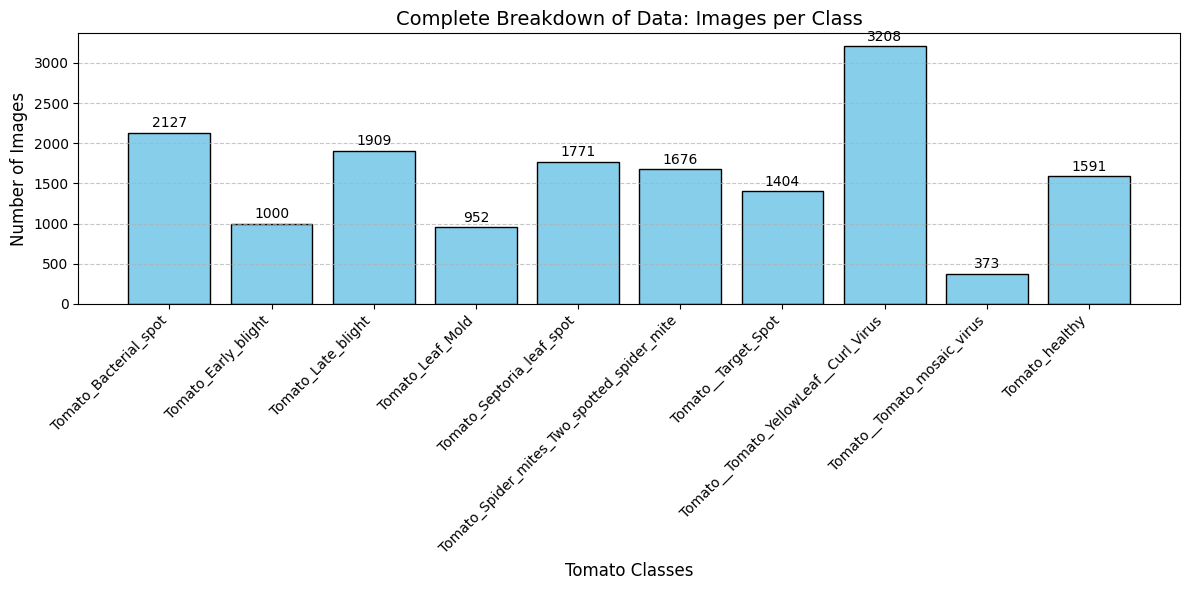


--- Visualizing Random Data Samples ---


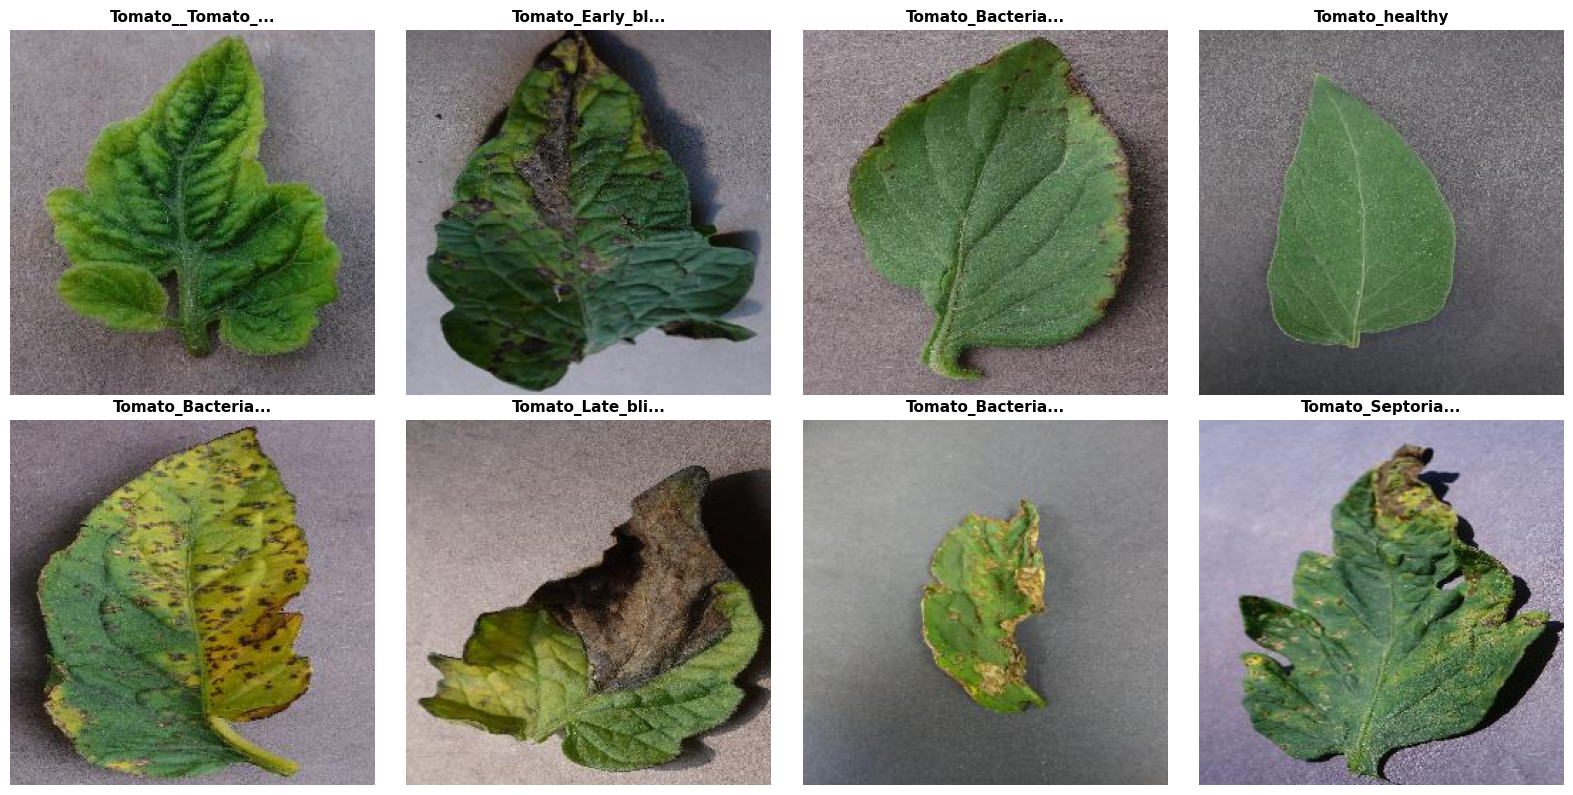

In [ ]:
import os
import shutil
import zipfile
import random
import matplotlib.pyplot as plt

# Define paths
drive_zip_path = '/content/drive/MyDrive/Bsc_Thesis/PlantVillage_Tomato.zip'
local_zip_path = '/content/PlantVillage_Tomato.zip'
extract_dir = '/content/PlantVillage_Tomato'

# 1. Copy the file from Google Drive to local /content directory
if os.path.exists(drive_zip_path):
    shutil.copy(drive_zip_path, local_zip_path)
    print(f"Copied {drive_zip_path} to {local_zip_path}")
else:
    print(f"Note: {drive_zip_path} not found. Assuming zip is already present in /content.")

# 2. Unzip quietly to avoid I/O bottlenecks
if os.path.exists(local_zip_path):
    with zipfile.ZipFile(local_zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_dir)
    print("Extraction complete.\n")

# 3. Verification & Complete Breakdown
num_classes = 0
total_images = 0
class_counts = {}
valid_extensions = {'.jpg', '.jpeg', '.png', '.JPG', '.JPEG', '.PNG'}

if os.path.exists(extract_dir):
    # Get all subdirectories (classes)
    subdirs = sorted([d for d in os.listdir(extract_dir) if os.path.isdir(os.path.join(extract_dir, d))])
    num_classes = len(subdirs)

    # Count images per class
    for subdir in subdirs:
        class_path = os.path.join(extract_dir, subdir)
        count = len([f for f in os.listdir(class_path) if os.path.splitext(f)[1] in valid_extensions])
        class_counts[subdir] = count
        total_images += count

print("--- Data Breakdown ---")
print(f"Number of sub-directories (classes): {num_classes}")
print(f"Total number of extracted image files: {total_images}\n")

# Print the exact number of images per class
print("--- Exact Image Counts per Class ---")
for class_name, count in class_counts.items():
    print(f"{class_name}: {count} images")
print("-" * 36 + "\n")

# 4. Plot the breakdown
if class_counts:
    print("Generating complete data breakdown plot...")
    classes = list(class_counts.keys())
    counts = list(class_counts.values())

    plt.figure(figsize=(12, 6))
    plt.bar(classes, counts, color='skyblue', edgecolor='black')

    # Add exact numbers on top of the bars in the plot
    for i, v in enumerate(counts):
        plt.text(i, v + (max(counts)*0.01), str(v), ha='center', va='bottom', fontsize=10)

    plt.xticks(rotation=45, ha='right')
    plt.xlabel('Tomato Classes', fontsize=12)
    plt.ylabel('Number of Images', fontsize=12)
    plt.title('Complete Breakdown of Data: Images per Class', fontsize=14)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

# 5. Visualizing Data Samples
print("\n--- Visualizing Random Data Samples ---")
if class_counts:
    all_image_paths = []

    # Pool all valid image paths across all classes
    for subdir in subdirs:
        class_path = os.path.join(extract_dir, subdir)
        for f in os.listdir(class_path):
            if os.path.splitext(f)[1] in valid_extensions:
                all_image_paths.append((os.path.join(class_path, f), subdir))

    # Ensure we don't try to sample more images than exist
    sample_size = min(8, len(all_image_paths))

    if sample_size > 0:
        samples = random.sample(all_image_paths, sample_size)

        plt.figure(figsize=(16, 8))
        for i, (img_path, label) in enumerate(samples):
            plt.subplot(2, 4, i + 1)

            # Read and plot the image
            img = plt.imread(img_path)
            plt.imshow(img)

            # Truncate long class names for a cleaner display
            short_label = label[:15] + "..." if len(label) > 15 else label
            plt.title(short_label, fontsize=11, fontweight='bold')
            plt.axis('off')

        plt.tight_layout()
        plt.show()
    else:
        print("No valid images found to display.")

# Salient Object Detection (SOD)

In [ ]:
!pip uninstall -y onnxruntime onnxruntime-gpu rembg
# Install version compatible with Colab's CUDA 12.x environment
!pip install onnxruntime-gpu==1.20.1 rembg[gpu]

Found existing installation: onnxruntime-gpu 1.20.1
Uninstalling onnxruntime-gpu-1.20.1:
  Successfully uninstalled onnxruntime-gpu-1.20.1
Found existing installation: rembg 2.0.69
Uninstalling rembg-2.0.69:
  Successfully uninstalled rembg-2.0.69
  Using cached onnxruntime_gpu-1.20.1-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (4.5 kB)
  Using cached rembg-2.0.77-py3-none-any.whl.metadata (18 kB)
INFO: pip is looking at multiple versions of rembg[gpu] to determine which version is compatible with other requirements. This could take a while.
  Using cached rembg-2.0.76-py3-none-any.whl.metadata (18 kB)
  Using cached rembg-2.0.75-py3-none-any.whl.metadata (17 kB)
  Using cached rembg-2.0.74-py3-none-any.whl.metadata (17 kB)
  Using cached rembg-2.0.73-py3-none-any.whl.metadata (17 kB)
  Using cached rembg-2.0.72-py3-none-any.whl.metadata (16 kB)
  Using cached rembg-2.0.71-py3-none-any.whl.metadata (16 kB)
  Using cached rembg-2.0.70-py3-none-any.whl.metadata (

In [ ]:
import sys
import importlib

# Force refresh the onnxruntime module to clear the version mismatch in memory
if 'onnxruntime' in sys.modules:
    importlib.reload(sys.modules['onnxruntime'])

import onnxruntime as ort

providers = ort.get_available_providers()
print("Available Providers:", providers)

if 'CUDAExecutionProvider' in providers:
    print("\n✅ SUCCESS: The GPU is locked, loaded, and ready for extreme speed.")
else:
    print("\n❌ FAILED: Still stuck on CPU. Please restart the runtime (Runtime > Restart session) and run the cells again.")

Available Providers: ['TensorrtExecutionProvider', 'CUDAExecutionProvider', 'CPUExecutionProvider']

✅ SUCCESS: The GPU is locked, loaded, and ready for extreme speed.


###  Data Segmentation

Before feeding images into the CNN architectures, it was crucial to isolate the tomato leaves from their backgrounds to ensure the models learned disease-specific features rather than environmental noise. This was achieved using the `rembg` (U^2-Net) library.

To handle the massive PlantVillage dataset efficiently, the preprocessing script was heavily optimized for speed, memory management, and GPU utilization.

**1. Hardware Acceleration (CUDA Validation)**
The pipeline begins by strictly verifying that the ONNX Runtime has access to the `CUDAExecutionProvider`. This ensures the U^2-Net segmentation model runs entirely on the GPU's VRAM, preventing a massive slowdown from CPU fallback.

**2. Asynchronous I/O Pipeline**
To prevent the GPU from sitting idle while waiting for the hard drive to read or write images, the workload was split into specialized functions and executed asynchronously using a `ThreadPoolExecutor` with 12 workers:
*   **`read_image(file_path)`:** An I/O-bound function dedicated solely to fetching images from the disk into RAM. If it detects a corrupted file, it flags it for deletion.
*   **`process_and_save(file_path, img_rgb)`:** The compute-heavy core function. It pushes the RAM-loaded image to the GPU for segmentation. As the workers pre-fetch images, the GPU processes them in a continuous stream without bottlenecking.

**3. Alpha Channel Masking & Background Standardization**
Once the GPU extracts the leaf, it returns an RGBA image (where the background is transparent). Because standard CNNs expect 3-channel RGB inputs, the `process_and_save` function dynamically manipulates the alpha channel. It isolates the extracted leaf and mathematically blends it over a pure black background (`np.zeros_like`). This standardizes the input space, ensuring the neural networks aren't confused by transparent pixels or random background colors.

**4. Automated Cloud Archiving**
Finally, to secure the processed dataset for the remainder of the thesis work, the pipeline directly compresses the segmented directory into a `.zip` file and streams it straight to Google Drive (`shutil.make_archive`), completely automating the backup process.

In [ ]:
import os
import cv2
import numpy as np
import onnxruntime as ort
from rembg import remove, new_session
import concurrent.futures

# --- 1. GPU Verification ---
# We must strictly verify ONNX is seeing the GPU, otherwise it falls back to CPU.
providers = ort.get_available_providers()
if 'CUDAExecutionProvider' not in providers:
    print("WARNING: CUDA is not available! The environment will fall back to CPU and run slowly.")
    print("Please ensure your Colab runtime is set to T4 GPU (Runtime > Change runtime type).")
else:
    print("SUCCESS: CUDA Execution Provider detected. VRAM acceleration unlocked.")

print("\n--- Phase A: Initiating Extreme-Speed GPU Segmentation ---")

# CRITICAL FIX: Explicitly command the session to use the GPU Provider
session = new_session("u2net", providers=['CUDAExecutionProvider'])

extract_dir = '/content/PlantVillage_Tomato'
corrupted_deleted = 0
images_segmented = 0

# Gather all images
all_files = []
for root, dirs, files in os.walk(extract_dir):
    for file in files:
        if file.lower().endswith(('.png', '.jpg', '.jpeg')):
            all_files.append(os.path.join(root, file))

total_files = len(all_files)
print(f"Found {total_files} images. Engaging asynchronous processing pipeline...\n")

# --- 2. Asynchronous Functions ---
# We separate reading/writing (CPU/Disk) from inference (GPU) to prevent bottlenecks.

def read_image(file_path):
    """Reads image from disk (I/O bound)"""
    img_bgr = cv2.imread(file_path)
    if img_bgr is None:
        return file_path, None
    return file_path, cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

def process_and_save(file_path, img_rgb):
    """Processes via GPU and writes back to disk (Compute + I/O bound)"""
    try:
        # GPU Inference
        segmented_rgba = remove(img_rgb, session=session)

        # Channel manipulation (CPU)
        if segmented_rgba.shape[2] == 4:
            alpha_channel = segmented_rgba[:, :, 3]
            rgb_channels = segmented_rgba[:, :, :3]

            black_bg = np.zeros_like(rgb_channels)
            alpha_factor = alpha_channel[:, :, np.newaxis] / 255.0

            final_rgb = (rgb_channels * alpha_factor + black_bg * (1 - alpha_factor)).astype(np.uint8)
            final_bgr = cv2.cvtColor(final_rgb, cv2.COLOR_RGB2BGR)
        else:
            final_bgr = cv2.cvtColor(segmented_rgba, cv2.COLOR_RGB2BGR)

        # Write to disk
        cv2.imwrite(file_path, final_bgr)
        return True, file_path
    except Exception as e:
        return False, file_path

# --- 3. Pipeline Execution ---
# We use ThreadPoolExecutor to pre-fetch images into RAM so the GPU never has to wait.
with concurrent.futures.ThreadPoolExecutor(max_workers=12) as executor:
    # 1. Start reading all images into a generator
    future_to_path = {executor.submit(read_image, path): path for path in all_files}

    # 2. As images finish loading into RAM, immediately send them to the GPU
    for future in concurrent.futures.as_completed(future_to_path):
        path, img_rgb = future.result()

        if img_rgb is None:
            os.remove(path)
            corrupted_deleted += 1
            continue

        # GPU processes the image and saves it
        success, finished_path = process_and_save(path, img_rgb)

        if success:
            images_segmented += 1
            if images_segmented % 1000 == 0:
                print(f"Processed {images_segmented} / {total_files} images...")
        else:
            os.remove(finished_path)
            corrupted_deleted += 1

print("\n--- Phase A Complete ---")
print(f"Deleted corrupted/failed files: {corrupted_deleted}")
print(f"Successfully Segmented: {images_segmented} images.")

import shutil
from google.colab import drive

print("--- 1. Mounting Google Drive ---")
# This will prompt you to authorize Colab to access your Drive
drive.mount('/content/drive')

# Define exactly what we are zipping and where it is going
folder_to_zip = '/content/PlantVillage_Tomato'
# We add "Segmented_" to the name so it sits right next to your original zip without overwriting it
output_filename = '/content/drive/MyDrive/Bsc_Thesis/Segmented_PlantVillage_Tomato'

print(f"\n--- 2. Archiving Directly to Google Drive ---")
print(f"Compressing files to: {output_filename}.zip")
print("This may take several minutes. Please do not close the notebook...\n")

# This zips the folder and streams it directly to your Google Drive
shutil.make_archive(output_filename, 'zip', folder_to_zip)

print("--- Export Complete! ---")
print("Your perfectly segmented AI dataset is now safely backed up for the rest of your thesis.")

SUCCESS: CUDA Execution Provider detected. VRAM acceleration unlocked.

--- Phase A: Initiating Extreme-Speed GPU Segmentation ---
Found 16011 images. Engaging asynchronous processing pipeline...

Processed 1000 / 16011 images...
Processed 2000 / 16011 images...
Processed 3000 / 16011 images...
Processed 4000 / 16011 images...
Processed 5000 / 16011 images...
Processed 6000 / 16011 images...
Processed 7000 / 16011 images...
Processed 8000 / 16011 images...
Processed 9000 / 16011 images...
Processed 10000 / 16011 images...
Processed 11000 / 16011 images...
Processed 12000 / 16011 images...
Processed 13000 / 16011 images...
Processed 14000 / 16011 images...
Processed 15000 / 16011 images...
Processed 16000 / 16011 images...

--- Phase A Complete ---
Deleted corrupted/failed files: 0
Successfully Segmented: 16011 images.
--- 1. Mounting Google Drive ---
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

--- 2. 

# Data Extraction (Segmented version)

Copied /content/drive/MyDrive/Bsc_Thesis/Segmented_PlantVillage_Tomato.zip to /content/PlantVillage_Tomato.zip
Extraction complete.

--- Data Breakdown ---
Number of sub-directories (classes): 10
Total number of extracted image files: 16011

--- Exact Image Counts per Class ---
Tomato_Bacterial_spot: 2127 images
Tomato_Early_blight: 1000 images
Tomato_Late_blight: 1909 images
Tomato_Leaf_Mold: 952 images
Tomato_Septoria_leaf_spot: 1771 images
Tomato_Spider_mites_Two_spotted_spider_mite: 1676 images
Tomato__Target_Spot: 1404 images
Tomato__Tomato_YellowLeaf__Curl_Virus: 3208 images
Tomato__Tomato_mosaic_virus: 373 images
Tomato_healthy: 1591 images
------------------------------------

Generating complete data breakdown plot...


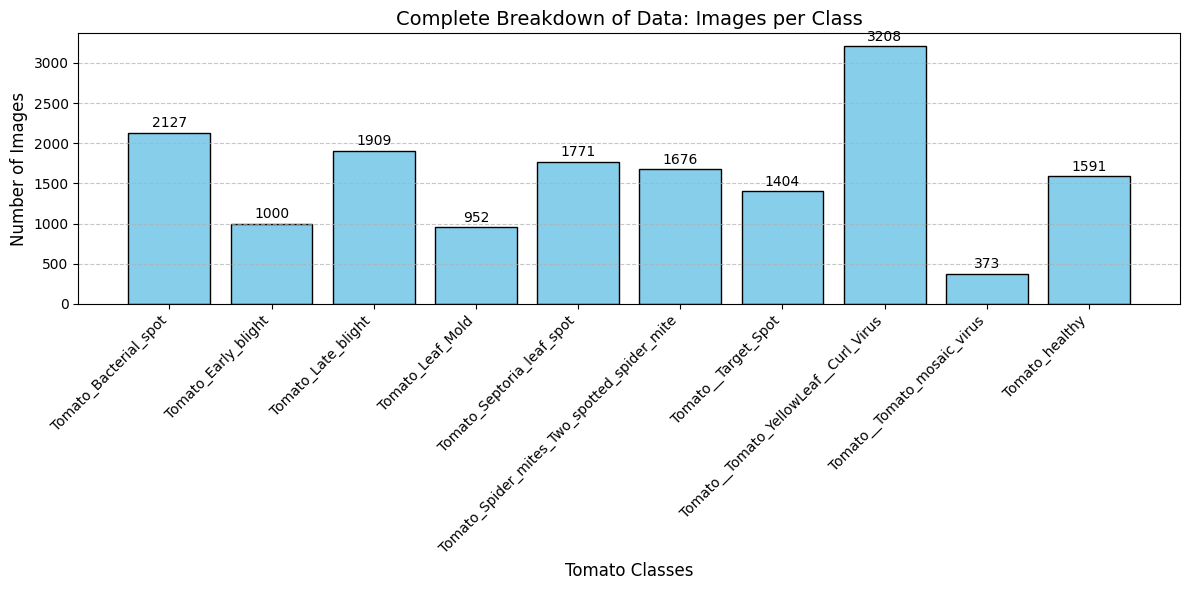


--- Visualizing Random Data Samples ---


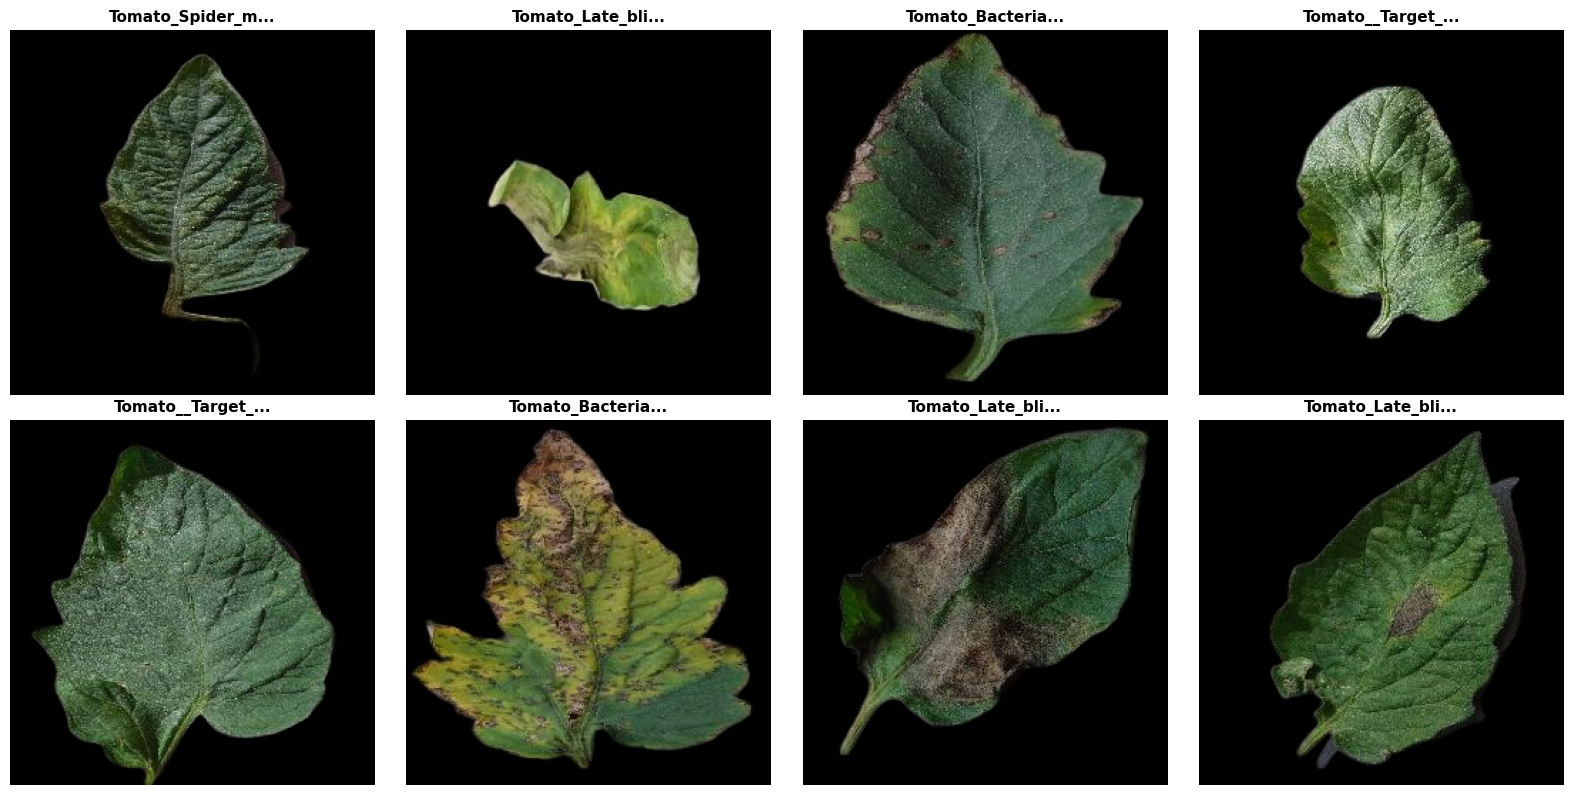

In [ ]:
import os
import shutil
import zipfile
import random
import matplotlib.pyplot as plt

# Define paths
drive_zip_path = '/content/drive/MyDrive/Bsc_Thesis/Segmented_PlantVillage_Tomato.zip'
local_zip_path = '/content/PlantVillage_Tomato.zip'
extract_dir = '/content/PlantVillage_Tomato'

# 1. Copy the file from Google Drive to local /content directory
if os.path.exists(drive_zip_path):
    shutil.copy(drive_zip_path, local_zip_path)
    print(f"Copied {drive_zip_path} to {local_zip_path}")
else:
    print(f"Note: {drive_zip_path} not found. Assuming zip is already present in /content.")

# 2. Unzip quietly to avoid I/O bottlenecks
if os.path.exists(local_zip_path):
    with zipfile.ZipFile(local_zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_dir)
    print("Extraction complete.\n")

# 3. Verification & Complete Breakdown
num_classes = 0
total_images = 0
class_counts = {}
valid_extensions = {'.jpg', '.jpeg', '.png', '.JPG', '.JPEG', '.PNG'}

if os.path.exists(extract_dir):
    # Get all subdirectories (classes)
    subdirs = sorted([d for d in os.listdir(extract_dir) if os.path.isdir(os.path.join(extract_dir, d))])
    num_classes = len(subdirs)

    # Count images per class
    for subdir in subdirs:
        class_path = os.path.join(extract_dir, subdir)
        count = len([f for f in os.listdir(class_path) if os.path.splitext(f)[1] in valid_extensions])
        class_counts[subdir] = count
        total_images += count

print("--- Data Breakdown ---")
print(f"Number of sub-directories (classes): {num_classes}")
print(f"Total number of extracted image files: {total_images}\n")

# Print the exact number of images per class
print("--- Exact Image Counts per Class ---")
for class_name, count in class_counts.items():
    print(f"{class_name}: {count} images")
print("-" * 36 + "\n")

# 4. Plot the breakdown
if class_counts:
    print("Generating complete data breakdown plot...")
    classes = list(class_counts.keys())
    counts = list(class_counts.values())

    plt.figure(figsize=(12, 6))
    plt.bar(classes, counts, color='skyblue', edgecolor='black')

    # Add exact numbers on top of the bars in the plot
    for i, v in enumerate(counts):
        plt.text(i, v + (max(counts)*0.01), str(v), ha='center', va='bottom', fontsize=10)

    plt.xticks(rotation=45, ha='right')
    plt.xlabel('Tomato Classes', fontsize=12)
    plt.ylabel('Number of Images', fontsize=12)
    plt.title('Complete Breakdown of Data: Images per Class', fontsize=14)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

# 5. Visualizing Data Samples
print("\n--- Visualizing Random Data Samples ---")
if class_counts:
    all_image_paths = []

    # Pool all valid image paths across all classes
    for subdir in subdirs:
        class_path = os.path.join(extract_dir, subdir)
        for f in os.listdir(class_path):
            if os.path.splitext(f)[1] in valid_extensions:
                all_image_paths.append((os.path.join(class_path, f), subdir))

    # Ensure we don't try to sample more images than exist
    sample_size = min(8, len(all_image_paths))

    if sample_size > 0:
        samples = random.sample(all_image_paths, sample_size)

        plt.figure(figsize=(16, 8))
        for i, (img_path, label) in enumerate(samples):
            plt.subplot(2, 4, i + 1)

            # Read and plot the image
            img = plt.imread(img_path)
            plt.imshow(img)

            # Truncate long class names for a cleaner display
            short_label = label[:15] + "..." if len(label) > 15 else label
            plt.title(short_label, fontsize=11, fontweight='bold')
            plt.axis('off')

        plt.tight_layout()
        plt.show()
    else:
        print("No valid images found to display.")

### Botanical Texture Enhancement (CLAHE)

With the background successfully removed, the next objective was to make the disease features—such as microscopic lesions, powdery mildew, and chlorotic spots—as distinct as possible for the neural networks. To achieve this without distorting the natural color of the leaves, **Contrast Limited Adaptive Histogram Equalization (CLAHE)** was applied.

**Key Technical Implementations:**

**1. Luminance Isolation via LAB Color Space**
Applying histogram equalization directly to RGB channels severely distorts the true colors of an image. Since color is a critical feature in plant disease detection (e.g., yellowing leaves vs. brown spots), the images were first converted from BGR to the LAB color space. The CLAHE algorithm was exclusively applied to the **L (Luminance) channel**, enhancing the structural textures of the leaf while leaving the **A and B (Color) channels** completely untouched.

**2. Background Protection via Binary Masking**
A known side effect of CLAHE is that it amplifies noise in homogenous regions—such as the pure black backgrounds generated in Step 1. To prevent the background from becoming noisy and confusing the models, a dynamic masking system was engineered:
*   **Thresholding:** A binary mask was generated by converting the image to grayscale and classifying any pixel strictly greater than `0` as the "leaf foreground."
*   **Bitwise Restoration:** After CLAHE was applied to the leaf, a bitwise AND operation was executed using the mask. This guaranteed that the background remained at an absolute zero (pure black) tensor value.

**3. Adaptive Contrast Parameters**
The CLAHE algorithm was initialized with a `clipLimit=2.0` and a `tileGridSize=(8, 8)`. This localized the contrast enhancement to small 8x8 pixel grids, preventing the over-amplification of noise while bringing out the fine, localized details of the botanical textures.

**4. Pipeline Visualization and Validation**
Before passing the dataset to the CNN architectures, a randomized visualization script was implemented. It dynamically sampled images across all subdirectories, truncated lengthy disease class names for readable formatting, and plotted them on a localized grid. This served as a final visual sanity check to confirm that both the U^2-Net segmentation and the CLAHE enhancement were applied flawlessly across the dataset.

--- Phase B: Initiating Botanical Texture Enhancement ---
Applying CLAHE to segmented leaves...

Enhanced 1000 images...
Enhanced 2000 images...
Enhanced 3000 images...
Enhanced 4000 images...
Enhanced 5000 images...
Enhanced 6000 images...
Enhanced 7000 images...
Enhanced 8000 images...
Enhanced 9000 images...
Enhanced 10000 images...
Enhanced 11000 images...
Enhanced 12000 images...
Enhanced 13000 images...
Enhanced 14000 images...
Enhanced 15000 images...
Enhanced 16000 images...

--- Phase B Complete ---
Successfully Enhanced: 16011 images.

--- Visualizing Random Data Samples ---


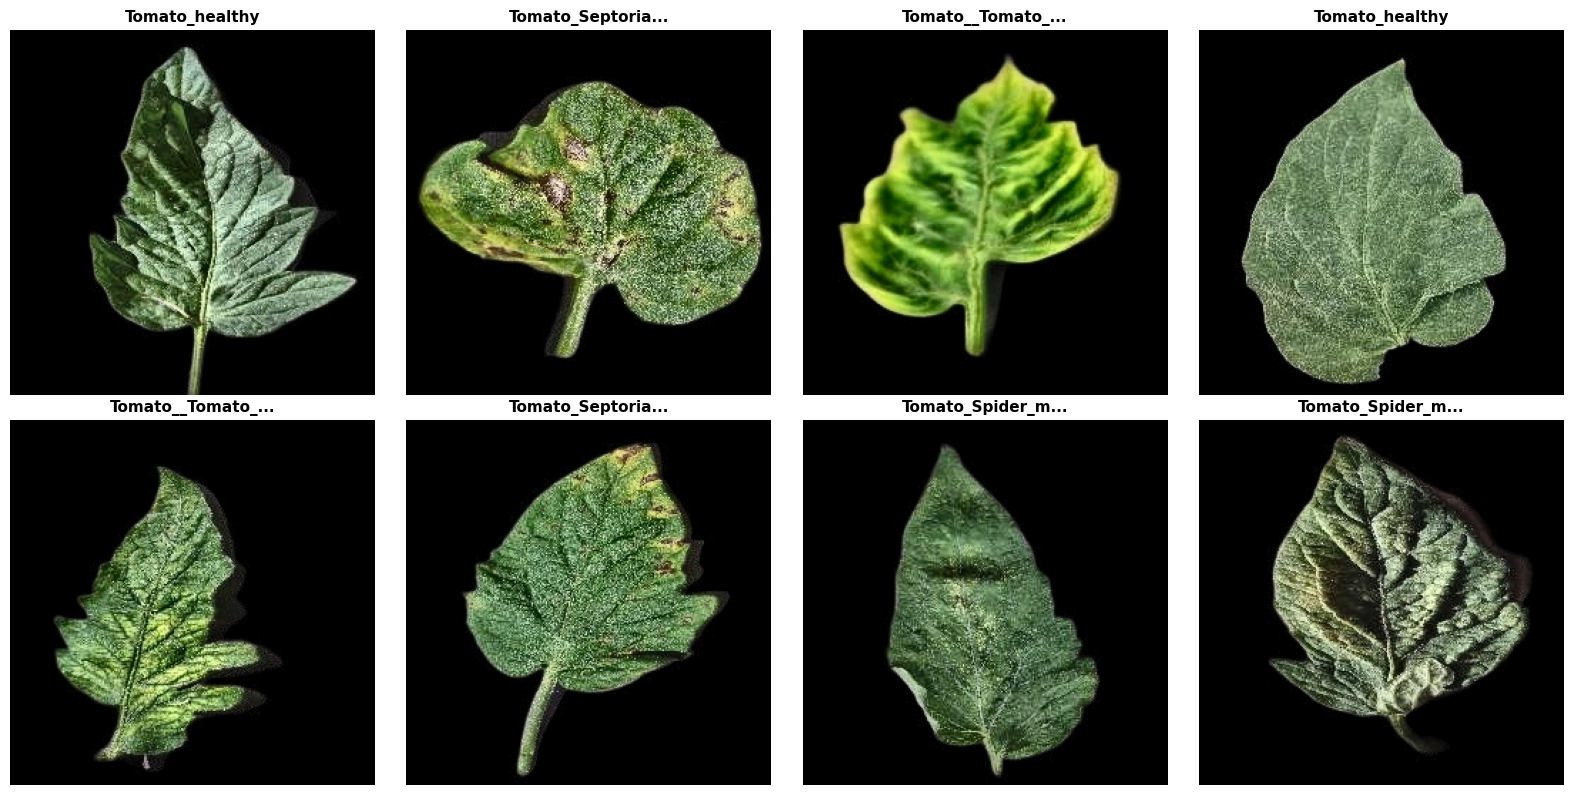

In [ ]:
import os
import cv2
import numpy as np

extract_dir = '/content/PlantVillage_Tomato'
images_enhanced = 0

# Initialize CLAHE algorithm
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))

print("--- Phase B: Initiating Botanical Texture Enhancement ---")
print("Applying CLAHE to segmented leaves...\n")

for root, dirs, files in os.walk(extract_dir):
    for file in files:
        if file.lower().endswith(('.png', '.jpg', '.jpeg')):
            file_path = os.path.join(root, file)

            img_bgr = cv2.imread(file_path)
            if img_bgr is None:
                continue

            try:
                # 1. Create a mask of the leaf to protect the pure black background
                # Any pixel that is strictly greater than 0 in any channel is part of the leaf
                gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
                _, mask = cv2.threshold(gray, 1, 255, cv2.THRESH_BINARY)

                # 2. Convert to LAB color space for luminance enhancement
                lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)
                l, a, b = cv2.split(lab)

                # Apply CLAHE to the L (Luminance) channel
                cl = clahe.apply(l)
                limg = cv2.merge((cl, a, b))

                # Convert back to BGR
                enhanced_bgr = cv2.cvtColor(limg, cv2.COLOR_LAB2BGR)

                # 3. Re-apply the mask to guarantee the background remains absolute zero (black)
                final_bgr = cv2.bitwise_and(enhanced_bgr, enhanced_bgr, mask=mask)

                # Overwrite the image
                cv2.imwrite(file_path, final_bgr)
                images_enhanced += 1

                if images_enhanced % 1000 == 0:
                    print(f"Enhanced {images_enhanced} images...")

            except Exception as e:
                print(f"Error enhancing {file_path}: {e}")

print("\n--- Phase B Complete ---")
print(f"Successfully Enhanced: {images_enhanced} images.")

# 5. Visualizing Data Samples
print("\n--- Visualizing Random Data Samples ---")
if class_counts:
    all_image_paths = []

    # Pool all valid image paths across all classes
    for subdir in subdirs:
        class_path = os.path.join(extract_dir, subdir)
        for f in os.listdir(class_path):
            if os.path.splitext(f)[1] in valid_extensions:
                all_image_paths.append((os.path.join(class_path, f), subdir))

    # Ensure we don't try to sample more images than exist
    sample_size = min(8, len(all_image_paths))

    if sample_size > 0:
        samples = random.sample(all_image_paths, sample_size)

        plt.figure(figsize=(16, 8))
        for i, (img_path, label) in enumerate(samples):
            plt.subplot(2, 4, i + 1)

            # Read and plot the image
            img = plt.imread(img_path)
            plt.imshow(img)

            # Truncate long class names for a cleaner display
            short_label = label[:15] + "..." if len(label) > 15 else label
            plt.title(short_label, fontsize=11, fontweight='bold')
            plt.axis('off')

        plt.tight_layout()
        plt.show()
    else:
        print("No valid images found to display.")

### Dataset Splitting and Memory-Optimized Pipeline

With the images segmented and enhanced, the dataset needed to be structured for the Convolutional Neural Networks. The data was loaded using the `tf.data` API, which allows for highly efficient, asynchronous batching.

To ensure rigorous evaluation and prevent data leakage, an **80/10/10 split** (Training / Validation / Testing) was enforced. The pipeline was also heavily optimized to prevent memory allocation crashes during model training.

**Key Technical Implementations:**

**1. Strict 80/10/10 Cardinality Split**
The dataset was initially loaded with a standard 80/20 training and validation split, resizing all images to `224x224` (the standard input requirement for ImageNet-pretrained architectures). To create a dedicated, untouched test set for final model evaluation, the 20% validation subset was perfectly bisected. Using the dataset's batch cardinality, `take()` and `skip()` operations were applied to allocate exactly 10% of the data to validation and 10% to testing.

**2. RAM-Safe Optimization (Crash-Proofing)**
Processing thousands of 224x224 images can easily exceed standard hardware limits (such as a 12GB RAM environment). To engineer a crash-proof pipeline, a targeted caching strategy was deployed:
*   **Training Set (80%):** The `.cache()` method was deliberately omitted for the training data. Forcing the entire training set into memory would cause an immediate RAM explosion. Instead, the data is streamed dynamically from the disk.
*   **Validation & Test Sets (10% each):** Because these subsets are much smaller, they *were* cached in memory. This is especially critical for the test set, as caching bypasses the heavy disk-read penalty that occurs when using the `.skip()` operation on a dataset stream.

**3. Asynchronous Prefetching**
To ensure the GPU never had to wait for the CPU to load the next batch of images, `tf.data.AUTOTUNE` was utilized across all three splits. By chaining the `.prefetch()` method to the datasets, the CPU prepares the next batch in the background while the GPU executes the forward and backward passes on the current batch, maximizing hardware efficiency.

In [ ]:
import tensorflow as tf

extract_dir = '/content/PlantVillage_Tomato'
BATCH_SIZE = 32
IMG_SIZE = (224, 224)
SEED = 42

print("--- Structuring the 80/10/10 Split ---")

# 1. Load the 80% Training Set
train_ds = tf.keras.utils.image_dataset_from_directory(
    extract_dir,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

# 2. Load the 20% Base Validation Set
base_val_ds = tf.keras.utils.image_dataset_from_directory(
    extract_dir,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
print(f"\nDetected {len(class_names)} disease classes.")

# 3. Split the 20% Base Validation into 10% Validation and 10% Test
print("Splitting base validation into strict val_ds and test_ds...")
val_batches = base_val_ds.cardinality().numpy()
test_batches = val_batches // 2

test_ds = base_val_ds.take(test_batches)
val_ds = base_val_ds.skip(test_batches)

# 4. Apply the RAM-Safe Optimizations
print("Applying RAM-Safe Optimizations...")
AUTOTUNE = tf.data.AUTOTUNE

# THE CRITICAL FIX: No .cache() on train_ds to prevent the 12GB RAM explosion
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)

# .cache() on val/test is safe and prevents the .skip() disk-read penalty
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

# 5. Final Verification
print("\n--- Cardinality Verification (Number of Batches) ---")
print(f"train_ds batches: {train_ds.cardinality().numpy()}")
print(f"val_ds batches:   {val_ds.cardinality().numpy()}")
print(f"test_ds batches:  {test_ds.cardinality().numpy()}")
print("\nSUCCESS: The pipeline is armed, optimized, and crash-proof.")

--- Structuring the 80/10/10 Split ---
Found 16011 files belonging to 10 classes.
Using 12809 files for training.
Found 16011 files belonging to 10 classes.
Using 3202 files for validation.

Detected 10 disease classes.
Splitting base validation into strict val_ds and test_ds...
Applying RAM-Safe Optimizations...

--- Cardinality Verification (Number of Batches) ---
train_ds batches: 401
val_ds batches:   51
test_ds batches:  50

SUCCESS: The pipeline is armed, optimized, and crash-proof.


# calculating the appropriate class weights

In [ ]:
import os

# 1. Use the class_names already stored in memory from the dataset initialization
num_classes = len(class_names)

# Initialize variables for counting
raw_class_counts = {}
total_dataset_images = 0
valid_extensions = {'.jpg', '.jpeg', '.png', '.JPG', '.JPEG', '.PNG'}

# 2. Iterate through directories and count images per class
for class_name in class_names:
    class_dir_path = os.path.join(extract_dir, class_name)
    if os.path.exists(class_dir_path):
        count = len([f for f in os.listdir(class_dir_path) if os.path.splitext(f)[1] in valid_extensions])
        raw_class_counts[class_name] = count
        total_dataset_images += count
    else:
        raw_class_counts[class_name] = 0

# 3. Calculate Class Weights
# Standard formula: weight = (1 / class_count) * (total_images / num_classes)
class_weights = {}
for i, class_name in enumerate(class_names):
    count = raw_class_counts[class_name]
    if count > 0:
        weight = (1 / count) * (total_dataset_images / num_classes)
    else:
        weight = 0.0
    class_weights[i] = weight

# 4. Output for Verification
print("--- Raw Image Count Per Class ---")
for i, class_name in enumerate(class_names):
    print(f"Index {i} | {class_name}: {raw_class_counts[class_name]} images")

print("\n--- Final Generated class_weights Dictionary ---")
print(class_weights)

--- Raw Image Count Per Class ---
Index 0 | Tomato_Bacterial_spot: 2127 images
Index 1 | Tomato_Early_blight: 1000 images
Index 2 | Tomato_Late_blight: 1909 images
Index 3 | Tomato_Leaf_Mold: 952 images
Index 4 | Tomato_Septoria_leaf_spot: 1771 images
Index 5 | Tomato_Spider_mites_Two_spotted_spider_mite: 1676 images
Index 6 | Tomato__Target_Spot: 1404 images
Index 7 | Tomato__Tomato_YellowLeaf__Curl_Virus: 3208 images
Index 8 | Tomato__Tomato_mosaic_virus: 373 images
Index 9 | Tomato_healthy: 1591 images

--- Final Generated class_weights Dictionary ---
{0: 0.7527503526093088, 1: 1.6011, 2: 0.8387113672079622, 3: 1.6818277310924368, 4: 0.9040654997176735, 5: 0.955310262529833, 6: 1.1403846153846153, 7: 0.4990960099750623, 8: 4.292493297587131, 9: 1.00634820867379}


# data augmentation pipeline

--- 1. Defining GPU Spatial Augmentation ---
--- Extracting a batch for Visual Verification ---


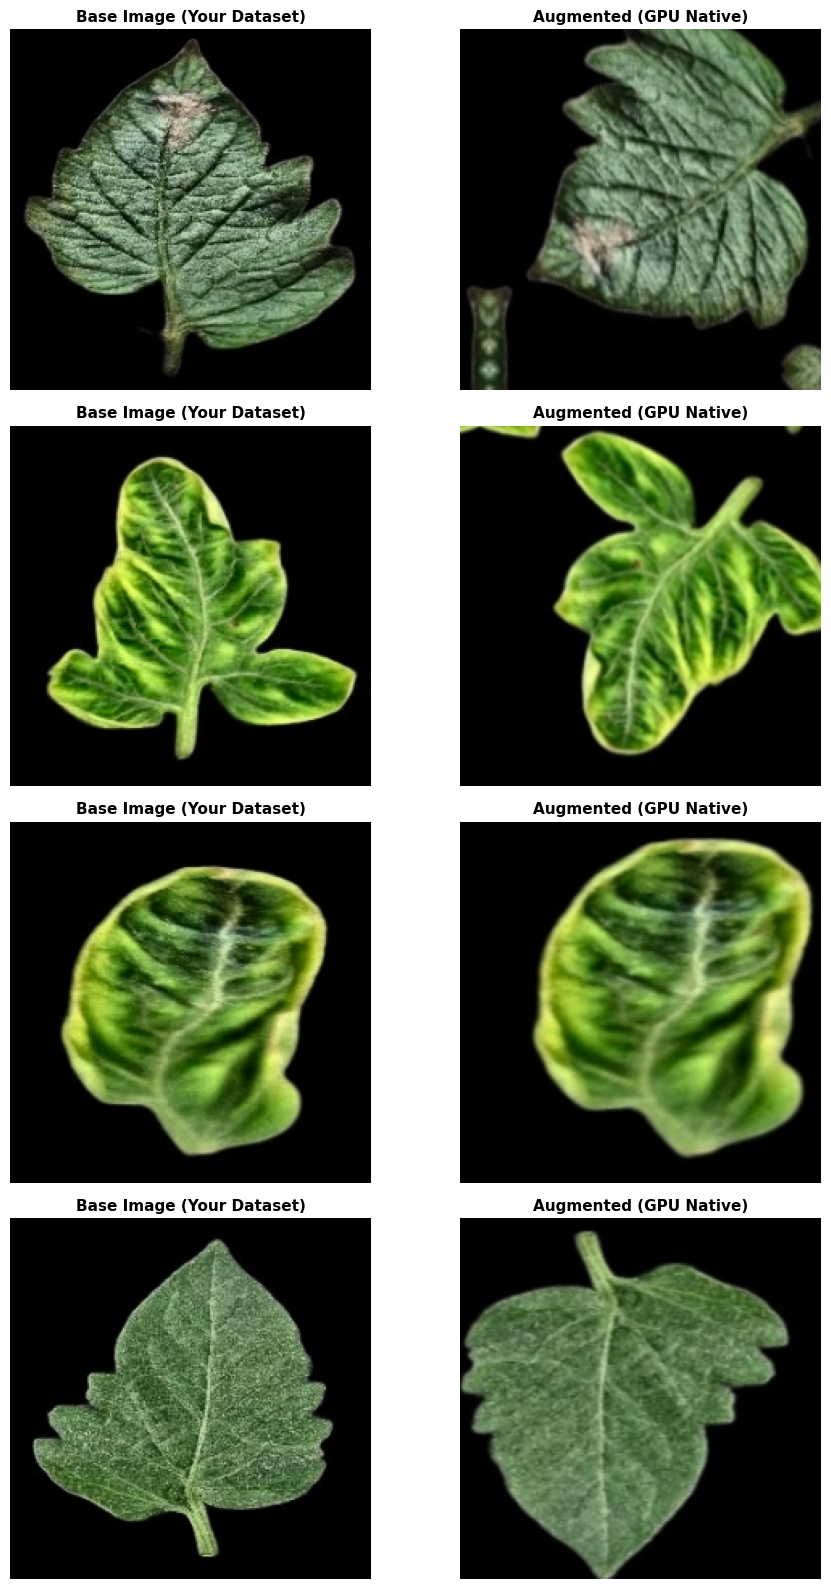

In [ ]:
# import matplotlib.pyplot as plt
# import tensorflow as tf

# print("--- 1. Defining GPU Spatial Augmentation ---")
# # Pure spatial transformations. No pixel scaling here.
# data_augmentation = tf.keras.Sequential([
#     tf.keras.layers.RandomFlip("horizontal_and_vertical"),
#     tf.keras.layers.RandomRotation(0.2),
#     tf.keras.layers.RandomTranslation(0.1, 0.1),
#     tf.keras.layers.RandomZoom(height_factor=(-0.1, 0.1))
# ], name="Fast_GPU_Augmentation")

# print("--- Extracting a batch for Visual Verification ---")
# # Pull directly from YOUR existing train_ds
# for images, labels in train_ds.take(1):
#     sample_images = images[:4]
#     break

# plt.figure(figsize=(10, 16))
# for i in range(4):
#     base_img = sample_images[i]

#     # Generate the augmented pair
#     aug_img = data_augmentation(tf.expand_dims(base_img, 0), training=True)[0]

#     # Plot Base Image
#     plt.subplot(4, 2, i * 2 + 1)
#     # We use cast to uint8 just in case your dataset is still 0-255
#     plt.imshow(tf.cast(base_img, tf.uint8).numpy())
#     plt.title("Base Image (Your Dataset)", fontsize=11, fontweight='bold')
#     plt.axis("off")

#     # Plot Augmented Image
#     plt.subplot(4, 2, i * 2 + 2)
#     plt.imshow(tf.cast(aug_img, tf.uint8).numpy())
#     plt.title("Augmented (GPU Native)", fontsize=11, fontweight='bold')
#     plt.axis("off")

# plt.tight_layout()
# plt.show()

--- Calculating Final Pipeline Statistics (Dynamic OS & Tensor Count) ---
Dynamically counting tensors in validation and test sets...

--- Final Enterprise Pipeline Statistics ---
**Training Set (`train_ds`)**
 - Total Images:  12809 (Calculated remainder of physical files)
 - Total Batches: 401
 - Batch Shape:   Images (None, 224, 224, 3), Labels (None,)

**Validation Set (`val_ds`)**
 - Total Images:  1602 (Dynamic Exact Count)
 - Total Batches: 51
 - Batch Shape:   Images (None, 224, 224, 3), Labels (None,)

**Test Set (`test_ds`)**
 - Total Images:  1600 (Dynamic Exact Count)
 - Total Batches: 50
 - Batch Shape:   Images (None, 224, 224, 3), Labels (None,)



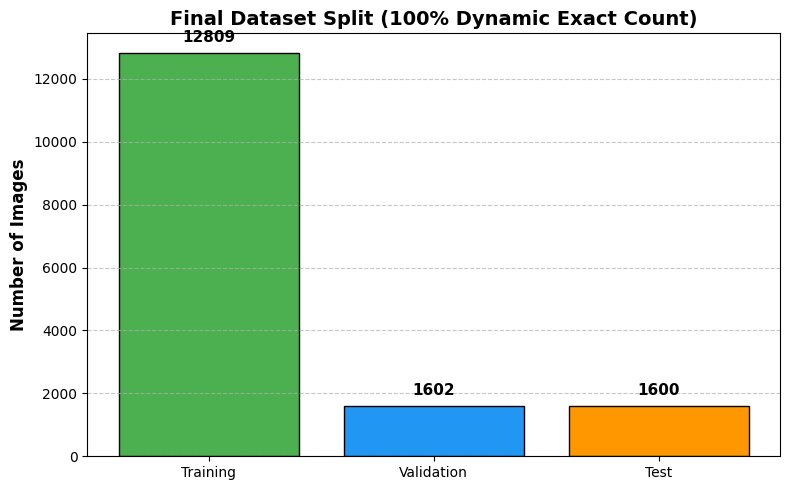

In [ ]:
import os
import matplotlib.pyplot as plt
import tensorflow as tf

print("--- Calculating Final Pipeline Statistics (Dynamic OS & Tensor Count) ---")

# 1. Get exact batch counts directly from metadata (0 RAM cost)
train_batches = train_ds.cardinality().numpy()
val_batches = val_ds.cardinality().numpy()
test_batches = test_ds.cardinality().numpy()

# 2. Extract EXACT image counts dynamically
extract_dir = '/content/PlantVillage_Tomato'

# Count every valid physical image sitting in your directories
total_physical_files = sum([
    len([f for f in files if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
    for r, d, files in os.walk(extract_dir)
])

# DYNAMIC COUNT: Safely iterate through the cached val and test sets to sum exact tensor shapes
print("Dynamically counting tensors in validation and test sets...")
val_images = sum(images.shape[0] for images, labels in val_ds)
test_images = sum(images.shape[0] for images, labels in test_ds)

# The training set is exactly the remainder of the total files
train_images = total_physical_files - (val_images + test_images)

# 3. Known Tensor Shapes
img_shape = "(None, 224, 224, 3)"
lbl_shape = "(None,)"

# --- Output for Verification ---
print("\n--- Final Enterprise Pipeline Statistics ---")
print("**Training Set (`train_ds`)**")
print(f" - Total Images:  {train_images} (Calculated remainder of physical files)")
print(f" - Total Batches: {train_batches}")
print(f" - Batch Shape:   Images {img_shape}, Labels {lbl_shape}\n")

print("**Validation Set (`val_ds`)**")
print(f" - Total Images:  {val_images} (Dynamic Exact Count)")
print(f" - Total Batches: {val_batches}")
print(f" - Batch Shape:   Images {img_shape}, Labels {lbl_shape}\n")

print("**Test Set (`test_ds`)**")
print(f" - Total Images:  {test_images} (Dynamic Exact Count)")
print(f" - Total Batches: {test_batches}")
print(f" - Batch Shape:   Images {img_shape}, Labels {lbl_shape}\n")

# --- Visual Breakdown of the Exact Data Split ---
splits = ['Training', 'Validation', 'Test']
counts = [train_images, val_images, test_images]

plt.figure(figsize=(8, 5))
plt.bar(splits, counts, color=['#4CAF50', '#2196F3', '#FF9800'], edgecolor='black')

for i, v in enumerate(counts):
    plt.text(i, v + (max(counts)*0.02), str(v), ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.title('Final Dataset Split (100% Dynamic Exact Count)', fontsize=14, fontweight='bold')
plt.ylabel('Number of Images', fontsize=12, fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Modular Model Architecture and Transfer Learning Setup

To evaluate and compare multiple backbones efficiently without writing redundant code, a dynamic model factory function (`build_health_engine`) was engineered. This function standardizes the initialization, preprocessing, and classification head configuration for **EfficientNetB0**, **ResNet50**, and **MobileNetV2**.

**Key Technical Implementations:**

**1. Architecture-Specific Preprocessing and Normalization**
Different pre-trained CNN architectures expect input tensors to be normalized within distinct value ranges. The function dynamically applies the precise preprocessing required by each model:
*   **EfficientNetB0:** Relies on its internal rescaling logic, taking raw tensor inputs directly.
*   **MobileNetV2:** Integrates a custom scaling layer (`scale=1./127.5, offset=-1.0`) to shift pixel values into the $[-1, 1]$ range.
*   **ResNet50:** Utilizes a dedicated wrapper (`tf.keras.applications.resnet50.preprocess_input`) to handle channel-wise mean subtraction as mandated by the original ImageNet training configuration.

**2. Transfer Learning and Feature Extraction**
To leverage powerful feature extractors trained on ImageNet while adapting them to botanical disease classification:
*   The base models were loaded with `include_top=False` and `pooling='avg'`, stripping away original classification layers and automatically applying Global Average Pooling to convert spatial feature maps into compact 1D feature vectors.
*   The backbone weights were strictly locked (`base.trainable = False`) to preserve pre-learned edge, texture, and shape representations during the initial phase of training.

**3. Custom Classification Head and Regularization**
A custom classification head was appended to the feature extraction base:
*   A **Dropout layer (rate=0.2)** was introduced to prevent overfitting by randomly dropping a fraction of weights during training updates.
*   A **Dense output layer** with **10 units** (corresponding to the distinct tomato plant classes) and a **softmax activation function** was used to output multi-class probability distributions.

**4. Model Compilation**
The models were compiled using the **Adam optimizer** for adaptive learning rate optimization, paired with **sparse categorical crossentropy** as the loss function—which efficiently handles integer-encoded class labels without requiring one-hot vector conversions.

In [ ]:
def build_health_engine(base_model_name):
    inputs = tf.keras.Input(shape=(224, 224, 3))

    # WE BYPASS AUGMENTATION ENTIRELY
    x = inputs

    # Perfect Math Layers (Still required for speed and accuracy)
    if base_model_name == 'EfficientNetB0':
        base = tf.keras.applications.EfficientNetB0(include_top=False, weights='imagenet', pooling='avg')
        x = base(x, training=False)

    elif base_model_name == 'MobileNetV2':
        x = tf.keras.layers.Rescaling(scale=1./127.5, offset=-1.0)(x)
        base = tf.keras.applications.MobileNetV2(include_top=False, weights='imagenet', pooling='avg')
        x = base(x, training=False)

    elif base_model_name == 'ResNet50':
        x = tf.keras.layers.Lambda(tf.keras.applications.resnet50.preprocess_input)(x)
        base = tf.keras.applications.ResNet50(include_top=False, weights='imagenet', pooling='avg')
        x = base(x, training=False)

    base.trainable = False # Keep it locked!

    x = tf.keras.layers.Dropout(0.2)(x)
    outputs = tf.keras.layers.Dense(10, activation='softmax')(x)

    model = tf.keras.Model(inputs=inputs, outputs=outputs)
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

    return model

# The Benchmarking Loop (Training)

In [ ]:
import tensorflow as tf
import gc
import os
import time

print("--- 3. Initiating High-Speed Training ---")

# Apply disk cache directly to your existing variables for maximum speed
AUTOTUNE = tf.data.AUTOTUNE
fast_train_ds = train_ds.cache('/tmp/fast_train').prefetch(AUTOTUNE)
fast_val_ds = val_ds.cache('/tmp/fast_val').prefetch(AUTOTUNE)

EPOCHS = 10
model_architectures = ['MobileNetV2', 'EfficientNetB0', 'ResNet50']
histories = {}

for model_name in model_architectures:
    print(f"\n========== Booting {model_name} ==========")
    tf.keras.backend.clear_session()
    gc.collect()

    checkpoint_path = f"{model_name}_final_best.weights.h5"
    if os.path.exists(checkpoint_path):
        print(f"[{model_name}] Checkpoint found! Skipping.")
        continue

    model = build_health_engine(model_name)

    checkpoint_cb = tf.keras.callbacks.ModelCheckpoint(
        filepath=checkpoint_path, save_best_only=True, save_weights_only=True,
        monitor='val_accuracy', mode='max', verbose=1
    )

    print(f"Training {model_name}...")
    start_time = time.time()

    history = model.fit(
        fast_train_ds,  # Using the on-the-fly cached version of your dataset
        validation_data=fast_val_ds,
        epochs=EPOCHS,
        callbacks=[checkpoint_cb]
    )

    print(f"--- {model_name} Time: {(time.time() - start_time) / 60:.2f} minutes ---")
    histories[model_name] = history.history

print("\n=======================================================")
print("SUCCESS: Training completed securely on your pre-split data.")
print("=======================================================")

--- 3. Initiating High-Speed Training ---

========== Booting MobileNetV2 ==========


/tmp/ipykernel_3381/2329084225.py:14: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = tf.keras.applications.MobileNetV2(include_top=False, weights='imagenet', pooling='avg')


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training MobileNetV2...
Epoch 1/10
401/401 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step - accuracy: 0.5846 - loss: 1.2409
Epoch 1: val_accuracy improved from None to 0.82397, saving model to MobileNetV2_final_best.weights.h5

Epoch 1: finished saving model to MobileNetV2_final_best.weights.h5
401/401 ━━━━━━━━━━━━━━━━━━━━ 117s 236ms/step - accuracy: 0.7049 - loss: 0.8825 - val_accuracy: 0.8240 - val_loss: 0.5560
Epoch 2/10
400/401 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.8175 - loss: 0.5401
Epoch 2: val_accuracy improved from 0.82397 to 0.85144, saving model to MobileNetV2_final_best.weights.h5

Epoch 2: finished saving model to MobileNetV2_final_best.weights.h5
401/401 ━━━━━━━━━━━━━━━━━━━━ 35s 87ms/step - accuracy: 0.8257 - loss: 0.5211 - val_accuracy: 0.8514 - val_loss: 0.4684
Epoch 3/10
400/401 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.8415 - loss: 0.4573
Epoch 3: val_accuracy improved from 0.85144 to 0.86891, saving model to Mobile

# Comparative Transient Response (Visualization)

--- Step 13: Comparative Transient Response (Visualization) ---
Rendering performance curves...



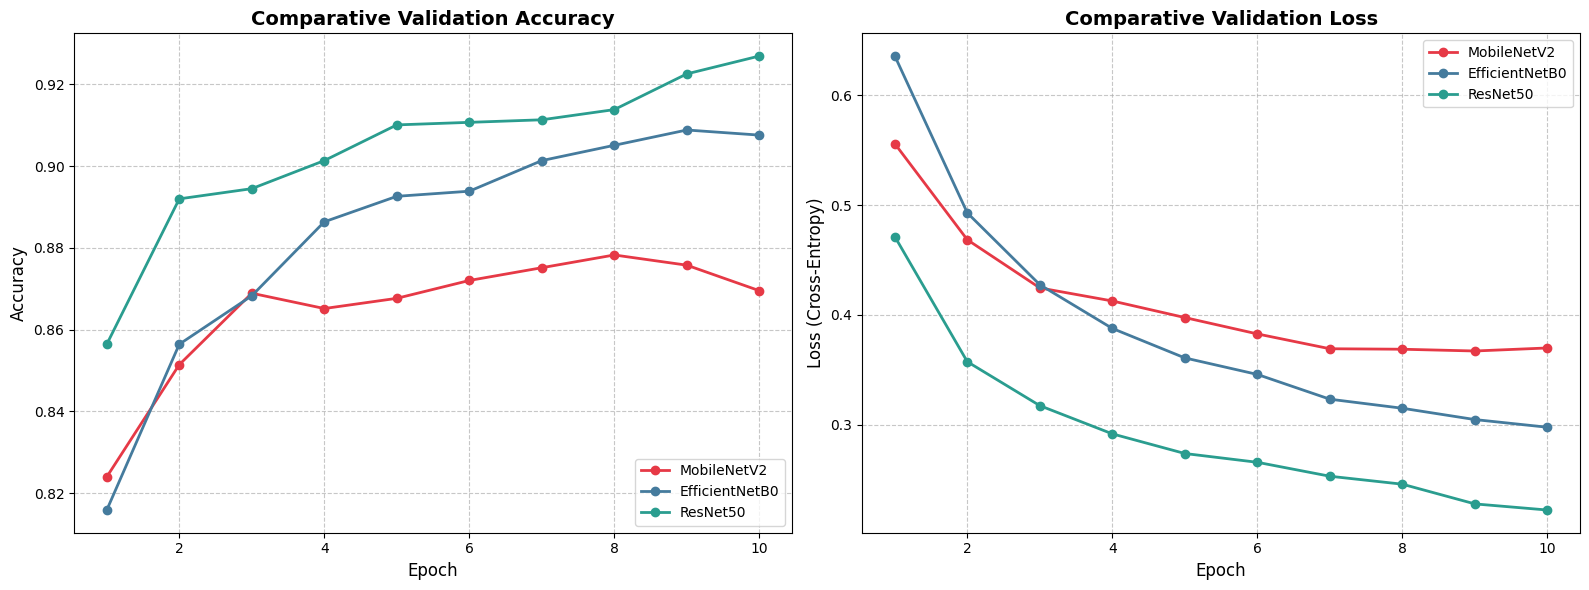

--- Visualization Rendered ---


In [ ]:
import matplotlib.pyplot as plt

print("--- Step 13: Comparative Transient Response (Visualization) ---")
print("Rendering performance curves...\n")

# Create a 1x2 subplot figure
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Define the models and their respective plot colors
architectures = ['MobileNetV2', 'EfficientNetB0', 'ResNet50']
colors = ['#E63946', '#457B9D', '#2A9D8F']  # Red, Blue, Green aesthetics

# --- Left Plot: Validation Accuracy ---
for model_name, color in zip(architectures, colors):
    if model_name in histories:
        val_acc = histories[model_name]['val_accuracy']
        epochs_range = range(1, len(val_acc) + 1)
        axes[0].plot(epochs_range, val_acc, label=model_name, color=color, linewidth=2, marker='o')

axes[0].set_title('Comparative Validation Accuracy', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].legend(loc='lower right')
axes[0].grid(axis='both', linestyle='--', alpha=0.7)

# --- Right Plot: Validation Loss ---
for model_name, color in zip(architectures, colors):
    if model_name in histories:
        val_loss = histories[model_name]['val_loss']
        epochs_range = range(1, len(val_loss) + 1)
        axes[1].plot(epochs_range, val_loss, label=model_name, color=color, linewidth=2, marker='o')

axes[1].set_title('Comparative Validation Loss', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Loss (Cross-Entropy)', fontsize=12)
axes[1].legend(loc='upper right')
axes[1].grid(axis='both', linestyle='--', alpha=0.7)

# Display the plots
plt.tight_layout()
plt.show()

print("--- Visualization Rendered ---")

### Fine-Tuning of EfficientNetB0

Following the initial feature-extraction phase, MobileNetV2 was eliminated due to comparatively lower performance. **EfficientNetB0** was selected as the primary architecture because it achieved a high baseline accuracy (~91.2%) while remaining computationally lightweight. To maximize its diagnostic precision, a targeted fine-tuning phase was executed.

**Key Technical Implementations:**

**1. Memory Initialization and Foundation Loading**
Before initiating deep training, the Keras backend session was cleared and garbage collection was explicitly called (`gc.collect()`). This freed up GPU VRAM and system memory, preventing Out-Of-Memory (OOM) crashes during the resource-intensive fine-tuning process. The previously trained optimal base weights were then restored.

**2. Targeted Layer Unfreezing**
Updating an entire pre-trained network from scratch risks "catastrophic forgetting," where the model loses its valuable ImageNet feature extractors. To prevent this, only the **top 30 layers** of the EfficientNetB0 base were unlocked. This strategy keeps the foundational edge and color detectors frozen, while allowing the deeper, high-level layers to adapt specifically to the intricate visual patterns of tomato plant diseases.

**3. Micro-Learning Rate Optimization**
The model was recompiled using the Adam optimizer with a drastically reduced learning rate (`1e-5`). This micro-learning rate is critical for fine-tuning; it ensures that weight updates are subtle and controlled, preventing the model from overshooting the optimal minimum on the loss landscape or destroying the pre-trained weights.

**4. Advanced Training Callbacks**
To automate the training loop and guarantee maximum performance without overfitting, a suite of dynamic callbacks was integrated:
*   **ModelCheckpoint:** Continuously monitored validation accuracy and saved strictly the best weight configurations.
*   **ReduceLROnPlateau:** Dynamically reduced the learning rate by a factor of 0.2 if the validation accuracy stagnated for 2 epochs, squeezing out residual performance gains.
*   **EarlyStopping:** Monitored the validation accuracy with a patience of 4 epochs. If the model began to overfit and stall, training was automatically halted, and the absolute best weights were seamlessly restored.

In [ ]:
import tensorflow as tf
import gc
import time

print("========== PHASE 2.5: FINE-TUNING EFFICIENTNET-B0 ==========")

tf.keras.backend.clear_session()
gc.collect()

# 1. Rebuild and Load the Phase 2 Foundation
model_name = 'EfficientNetB0'
model = build_health_engine(model_name)
model.load_weights(f"{model_name}_final_best.weights.h5")
print(f"✅ Foundation weights loaded. Base accuracy: ~91.2%")

# 2. Unfreeze the Top 30 Layers
for layer in model.layers:
    if isinstance(layer, tf.keras.Model): # Finds the pre-trained base inside your architecture
        layer.trainable = True

        # Freeze everything EXCEPT the top 30 layers
        for sub_layer in layer.layers[:-30]:
            sub_layer.trainable = False

        print("✅ Top 30 layers unlocked for deep learning.")
        break

# 3. Micro-Learning Rate Recompile
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5), # Critical for fine-tuning
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 4. Maximum Performance Callbacks
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath=f"{model_name}_FINETUNED_best.weights.h5",
    save_best_only=True, save_weights_only=True, monitor='val_accuracy', mode='max', verbose=1
)
lr_scheduler = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_accuracy', factor=0.2, patience=2, min_lr=1e-7, verbose=1
)
early_stopper = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy', patience=4, restore_best_weights=True, verbose=1
)

# 5. Execute Fine-Tuning
print(f"\n🚀 Initiating Deep Fine-Tuning for {model_name}...")
start_time = time.time()

history_eff = model.fit(
    fast_train_ds,
    validation_data=fast_val_ds,
    epochs=30,
    callbacks=[checkpoint, lr_scheduler, early_stopper]
)

print(f"\n--- {model_name} Fine-Tuning Complete in {(time.time() - start_time) / 60:.2f} minutes ---")

========== PHASE 2.5: FINE-TUNING EFFICIENTNET-B0 ==========
✅ Foundation weights loaded. Base accuracy: ~91.2%
✅ Top 30 layers unlocked for deep learning.

🚀 Initiating Deep Fine-Tuning for EfficientNetB0...
Epoch 1/30


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 6 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


401/401 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step - accuracy: 0.7930 - loss: 0.6205
Epoch 1: val_accuracy improved from None to 0.88951, saving model to EfficientNetB0_FINETUNED_best.weights.h5

Epoch 1: finished saving model to EfficientNetB0_FINETUNED_best.weights.h5
401/401 ━━━━━━━━━━━━━━━━━━━━ 96s 159ms/step - accuracy: 0.8221 - loss: 0.5315 - val_accuracy: 0.8895 - val_loss: 0.3383 - learning_rate: 1.0000e-05
Epoch 2/30
400/401 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 0.8609 - loss: 0.4108
Epoch 2: val_accuracy improved from 0.88951 to 0.90012, saving model to EfficientNetB0_FINETUNED_best.weights.h5

Epoch 2: finished saving model to EfficientNetB0_FINETUNED_best.weights.h5
401/401 ━━━━━━━━━━━━━━━━━━━━ 35s 88ms/step - accuracy: 0.8656 - loss: 0.3987 - val_accuracy: 0.9001 - val_loss: 0.3050 - learning_rate: 1.0000e-05
Epoch 3/30
400/401 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 0.8792 - loss: 0.3633
Epoch 3: val_accuracy improved from 0.90012 to 0.90886, saving model to Efficie

========== PHASE 3: COMPREHENSIVE EVALUATION FOR EfficientNetB0 ==========
✅ Loaded 10 disease classes.


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 58 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


✅ Loaded fine-tuned weights from: EfficientNetB0_FINETUNED_best.weights.h5

Calculating overall test dataset metrics...
50/50 ━━━━━━━━━━━━━━━━━━━━ 13s 33ms/step - accuracy: 0.9594 - loss: 0.1189

🎯 OVERALL TEST ACCURACY : 95.94%
📉 OVERALL TEST LOSS     : 0.1189

Extracting predictions across all test batches...


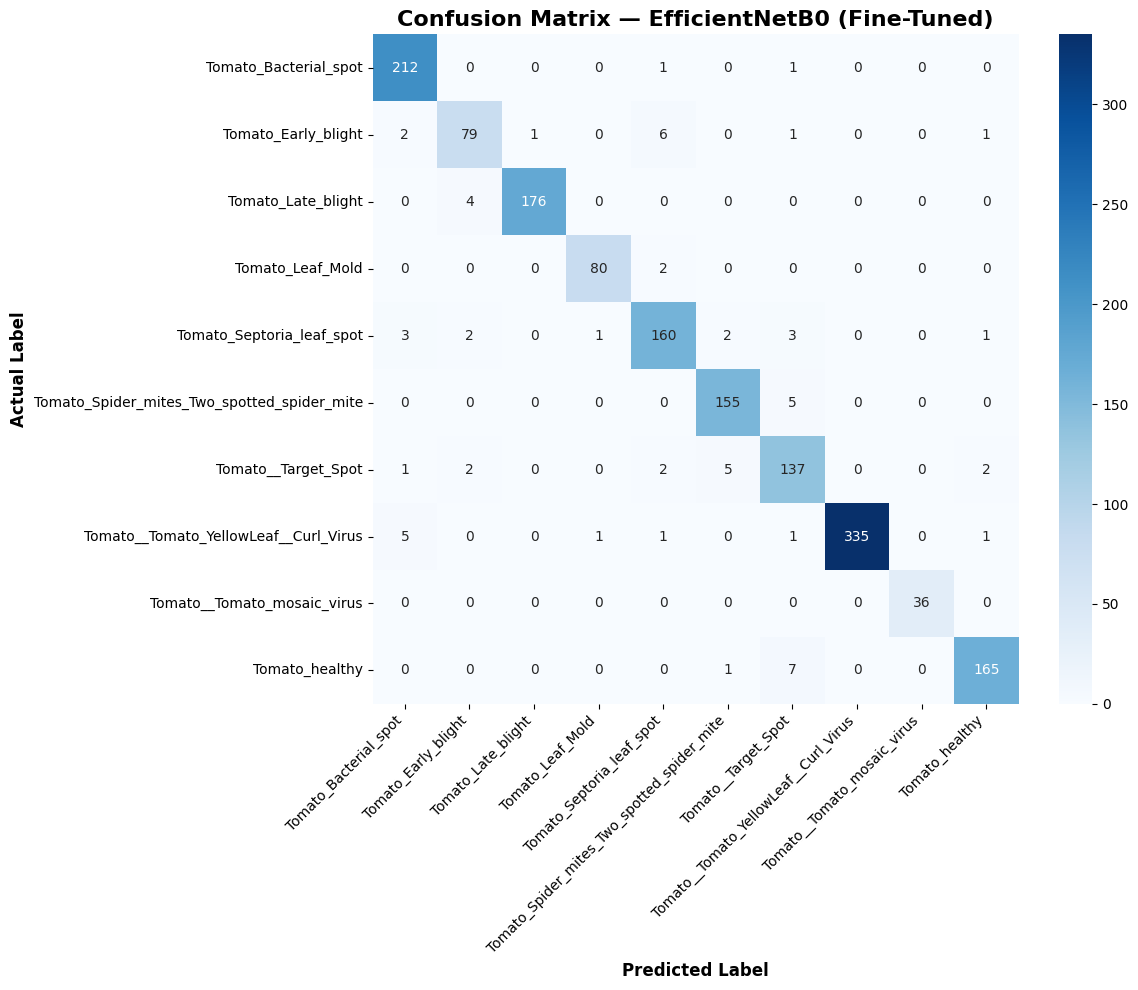


       CLASSIFICATION REPORT: EfficientNetB0
                                             precision    recall  f1-score   support

                      Tomato_Bacterial_spot       0.95      0.99      0.97       214
                        Tomato_Early_blight       0.91      0.88      0.89        90
                         Tomato_Late_blight       0.99      0.98      0.99       180
                           Tomato_Leaf_Mold       0.98      0.98      0.98        82
                  Tomato_Septoria_leaf_spot       0.93      0.93      0.93       172
Tomato_Spider_mites_Two_spotted_spider_mite       0.95      0.97      0.96       160
                        Tomato__Target_Spot       0.88      0.92      0.90       149
      Tomato__Tomato_YellowLeaf__Curl_Virus       1.00      0.97      0.99       344
                Tomato__Tomato_mosaic_virus       1.00      1.00      1.00        36
                             Tomato_healthy       0.97      0.95      0.96       173

                 

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os
from sklearn.metrics import classification_report, confusion_matrix

# ==============================================================================
#  'EfficientNetB0'
# ==============================================================================
EVAL_MODEL_NAME = 'EfficientNetB0'

print(f"========== PHASE 3: COMPREHENSIVE EVALUATION FOR {EVAL_MODEL_NAME} ==========")

# 1. Safely Extract Class Names (Handles tf.data transformation wrappers)
if hasattr(test_ds, 'class_names'):
    eval_class_names = test_ds.class_names
elif 'class_names' in globals() and class_names is not None:
    eval_class_names = class_names
else:
    # Fallback to reading the directory directly
    dataset_dir = '/content/PlantVillage_Tomato'
    eval_class_names = sorted([d for d in os.listdir(dataset_dir) if os.path.isdir(os.path.join(dataset_dir, d))])

print(f"✅ Loaded {len(eval_class_names)} disease classes.")

# 2. Prepare High-Speed Test Stream
AUTOTUNE = tf.data.AUTOTUNE
fast_test_ds = test_ds.cache().prefetch(AUTOTUNE)

# 3. Rebuild Architecture and Load Fine-Tuned Best Weights
model = build_health_engine(EVAL_MODEL_NAME)
weights_path = f"{EVAL_MODEL_NAME}_FINETUNED_best.weights.h5"

model.load_weights(weights_path)
print(f"✅ Loaded fine-tuned weights from: {weights_path}")

# 4. Overall Loss & Accuracy Evaluation
print("\nCalculating overall test dataset metrics...")
test_loss, test_acc = model.evaluate(fast_test_ds, verbose=1)
print(f"\n🎯 OVERALL TEST ACCURACY : {test_acc * 100:.2f}%")
print(f"📉 OVERALL TEST LOSS     : {test_loss:.4f}")

# 5. Generate Predictions & Map Ground Truth
print("\nExtracting predictions across all test batches...")
y_true = []
y_pred = []

for images, labels in fast_test_ds:
    preds = model.predict(images, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(labels.numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# 6. Confusion Matrix Heatmap
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12, 10))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=eval_class_names,
    yticklabels=eval_class_names
)
plt.title(f'Confusion Matrix — {EVAL_MODEL_NAME} (Fine-Tuned)', fontsize=16, fontweight='bold')
plt.ylabel('Actual Label', fontsize=12, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# 7. Detailed Classification Report (Precision, Recall, F1-Score)
print("\n" + "="*60)
print(f"       CLASSIFICATION REPORT: {EVAL_MODEL_NAME}")
print("="*60)
report_str = classification_report(y_true, y_pred, target_names=eval_class_names)
print(report_str)

# 8. Per-Class Accuracy Breakdown Table
cm_diag = cm.diagonal()
cm_sum = cm.sum(axis=1)
per_class_acc = (cm_diag / cm_sum) * 100

stats_df = pd.DataFrame({
    'Disease Class': eval_class_names,
    'Correct Predictions': cm_diag,
    'Total Samples': cm_sum,
    'Accuracy (%)': np.round(per_class_acc, 2)
})

print("\n" + "="*60)
print(f"       PER-CLASS ACCURACY BREAKDOWN: {EVAL_MODEL_NAME}")
print("="*60)
print(stats_df.to_string(index=False))

# Fine-Tune ResNet50

In [ ]:
import tensorflow as tf
import gc
import time

print("========== PHASE 2.5: FINE-TUNING RESNET-50 ==========")

tf.keras.backend.clear_session()
gc.collect()

# 1. Rebuild and Load the Phase 2 Foundation
model_name = 'ResNet50'
model = build_health_engine(model_name)
model.load_weights(f"{model_name}_final_best.weights.h5")
print(f"✅ Foundation weights loaded. Base accuracy: ~92.5%")

# 2. Unfreeze the Top 30 Layers
for layer in model.layers:
    if isinstance(layer, tf.keras.Model):
        layer.trainable = True

        # Freeze everything EXCEPT the top 30 layers
        for sub_layer in layer.layers[:-30]:
            sub_layer.trainable = False

        print("✅ Top 30 layers unlocked for deep learning.")
        break

# 3. Micro-Learning Rate Recompile
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 4. Maximum Performance Callbacks
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath=f"{model_name}_FINETUNED_best.weights.h5",
    save_best_only=True, save_weights_only=True, monitor='val_accuracy', mode='max', verbose=1
)
lr_scheduler = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_accuracy', factor=0.2, patience=2, min_lr=1e-7, verbose=1
)
early_stopper = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy', patience=4, restore_best_weights=True, verbose=1
)

# 5. Execute Fine-Tuning
print(f"\n🚀 Initiating Deep Fine-Tuning for {model_name}...")
start_time = time.time()

history_res = model.fit(
    fast_train_ds,
    validation_data=fast_val_ds,
    epochs=30,
    callbacks=[checkpoint, lr_scheduler, early_stopper]
)

print(f"\n--- {model_name} Fine-Tuning Complete in {(time.time() - start_time) / 60:.2f} minutes ---")

========== PHASE 2.5: FINE-TUNING RESNET-50 ==========
✅ Foundation weights loaded. Base accuracy: ~92.5%
✅ Top 30 layers unlocked for deep learning.

🚀 Initiating Deep Fine-Tuning for ResNet50...
Epoch 1/30


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 6 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


401/401 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step - accuracy: 0.7926 - loss: 1.0035
Epoch 1: val_accuracy improved from None to 0.94132, saving model to ResNet50_FINETUNED_best.weights.h5

Epoch 1: finished saving model to ResNet50_FINETUNED_best.weights.h5
401/401 ━━━━━━━━━━━━━━━━━━━━ 105s 206ms/step - accuracy: 0.8742 - loss: 0.4830 - val_accuracy: 0.9413 - val_loss: 0.2136 - learning_rate: 1.0000e-05
Epoch 2/30
401/401 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step - accuracy: 0.9589 - loss: 0.1204
Epoch 2: val_accuracy improved from 0.94132 to 0.94632, saving model to ResNet50_FINETUNED_best.weights.h5

Epoch 2: finished saving model to ResNet50_FINETUNED_best.weights.h5
401/401 ━━━━━━━━━━━━━━━━━━━━ 65s 163ms/step - accuracy: 0.9640 - loss: 0.1055 - val_accuracy: 0.9463 - val_loss: 0.1906 - learning_rate: 1.0000e-05
Epoch 3/30
401/401 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step - accuracy: 0.9814 - loss: 0.0576
Epoch 3: val_accuracy improved from 0.94632 to 0.94757, saving model to ResNet50_FINETUNED_best.wei

========== PHASE 3: COMPREHENSIVE EVALUATION FOR ResNet50 ==========
✅ Loaded 10 disease classes.


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 78 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


✅ Loaded fine-tuned weights from: ResNet50_FINETUNED_best.weights.h5

Calculating overall test dataset metrics...
50/50 ━━━━━━━━━━━━━━━━━━━━ 12s 87ms/step - accuracy: 0.9444 - loss: 0.1922

🎯 OVERALL TEST ACCURACY : 94.44%
📉 OVERALL TEST LOSS     : 0.1922

Extracting predictions across all test batches...


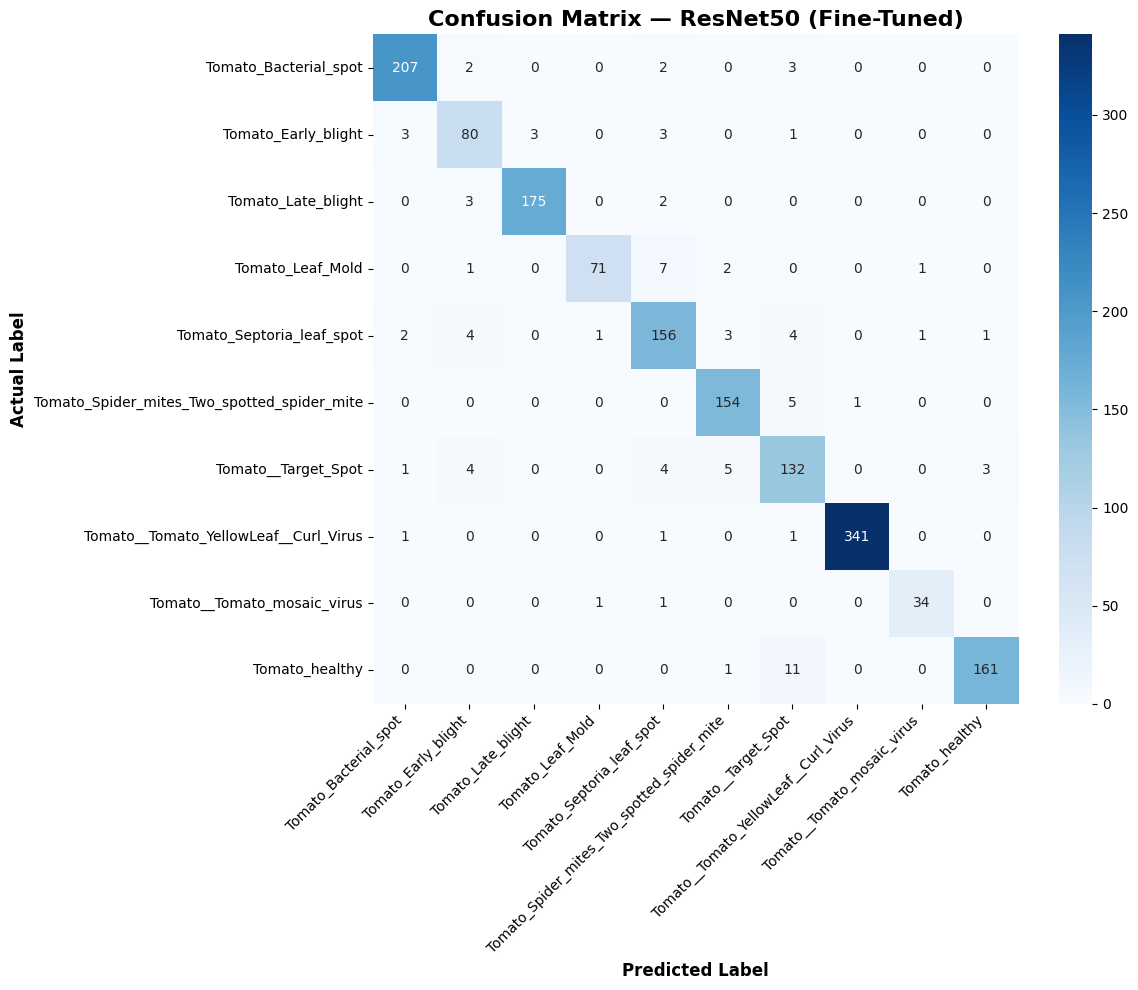


       CLASSIFICATION REPORT: ResNet50
                                             precision    recall  f1-score   support

                      Tomato_Bacterial_spot       0.97      0.97      0.97       214
                        Tomato_Early_blight       0.85      0.89      0.87        90
                         Tomato_Late_blight       0.98      0.97      0.98       180
                           Tomato_Leaf_Mold       0.97      0.87      0.92        82
                  Tomato_Septoria_leaf_spot       0.89      0.91      0.90       172
Tomato_Spider_mites_Two_spotted_spider_mite       0.93      0.96      0.95       160
                        Tomato__Target_Spot       0.84      0.89      0.86       149
      Tomato__Tomato_YellowLeaf__Curl_Virus       1.00      0.99      0.99       344
                Tomato__Tomato_mosaic_virus       0.94      0.94      0.94        36
                             Tomato_healthy       0.98      0.93      0.95       173

                       

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os
from sklearn.metrics import classification_report, confusion_matrix

# ==============================================================================
# 'ResNet50'
# ==============================================================================
EVAL_MODEL_NAME = 'ResNet50'

print(f"========== PHASE 3: COMPREHENSIVE EVALUATION FOR {EVAL_MODEL_NAME} ==========")

# 1. Safely Extract Class Names (Handles tf.data transformation wrappers)
if hasattr(test_ds, 'class_names'):
    eval_class_names = test_ds.class_names
elif 'class_names' in globals() and class_names is not None:
    eval_class_names = class_names
else:
    # Fallback to reading the directory directly
    dataset_dir = '/content/PlantVillage_Tomato'
    eval_class_names = sorted([d for d in os.listdir(dataset_dir) if os.path.isdir(os.path.join(dataset_dir, d))])

print(f"✅ Loaded {len(eval_class_names)} disease classes.")

# 2. Prepare High-Speed Test Stream
AUTOTUNE = tf.data.AUTOTUNE
fast_test_ds = test_ds.cache().prefetch(AUTOTUNE)

# 3. Rebuild Architecture and Load Fine-Tuned Best Weights
model = build_health_engine(EVAL_MODEL_NAME)
weights_path = f"{EVAL_MODEL_NAME}_FINETUNED_best.weights.h5"

model.load_weights(weights_path)
print(f"✅ Loaded fine-tuned weights from: {weights_path}")

# 4. Overall Loss & Accuracy Evaluation
print("\nCalculating overall test dataset metrics...")
test_loss, test_acc = model.evaluate(fast_test_ds, verbose=1)
print(f"\n🎯 OVERALL TEST ACCURACY : {test_acc * 100:.2f}%")
print(f"📉 OVERALL TEST LOSS     : {test_loss:.4f}")

# 5. Generate Predictions & Map Ground Truth
print("\nExtracting predictions across all test batches...")
y_true = []
y_pred = []

for images, labels in fast_test_ds:
    preds = model.predict(images, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(labels.numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# 6. Confusion Matrix Heatmap
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12, 10))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=eval_class_names,
    yticklabels=eval_class_names
)
plt.title(f'Confusion Matrix — {EVAL_MODEL_NAME} (Fine-Tuned)', fontsize=16, fontweight='bold')
plt.ylabel('Actual Label', fontsize=12, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# 7. Detailed Classification Report (Precision, Recall, F1-Score)
print("\n" + "="*60)
print(f"       CLASSIFICATION REPORT: {EVAL_MODEL_NAME}")
print("="*60)
report_str = classification_report(y_true, y_pred, target_names=eval_class_names)
print(report_str)

# 8. Per-Class Accuracy Breakdown Table
cm_diag = cm.diagonal()
cm_sum = cm.sum(axis=1)
per_class_acc = (cm_diag / cm_sum) * 100

stats_df = pd.DataFrame({
    'Disease Class': eval_class_names,
    'Correct Predictions': cm_diag,
    'Total Samples': cm_sum,
    'Accuracy (%)': np.round(per_class_acc, 2)
})

print("\n" + "="*60)
print(f"       PER-CLASS ACCURACY BREAKDOWN: {EVAL_MODEL_NAME}")
print("="*60)
print(stats_df.to_string(index=False))

### Final Evaluation and Diagnostic Analytics

To determine the true generalization capability of the fine-tuned EfficientNetB0 model, it was strictly evaluated against the 10% test set—a purely unseen data partition engineered in Step 3. Rather than relying solely on global accuracy, the evaluation pipeline was designed to provide granular, class-specific diagnostic insights.

**Key Technical Implementations:**

**1. High-Speed Inference Pipeline**
Just like the training phase, the test dataset was optimized using `tf.data.AUTOTUNE`, chaining `.cache()` and `.prefetch()` methods. This ensured that the CPU fed image batches into the GPU as fast as the model could execute forward passes, significantly accelerating the extraction of predictions.

**2. Strict Weight Restoration**
To guarantee the evaluation reflected peak performance, the model architecture was cleanly re-instantiated, and the optimal fine-tuned weights—captured dynamically by the `ModelCheckpoint` callback during training—were restored. This avoided evaluating a potentially overfitted model from the final epoch.

**3. Comprehensive Confusion Matrix (Seaborn)**
To visually diagnose where the neural network struggled, an annotated heatmap was generated using Scikit-Learn and Seaborn. By mapping actual labels against predicted labels, this matrix immediately highlights specific inter-class confusion (for instance, if the model frequently mistakes "Early Blight" for "Late Blight" due to visual similarities).

**4. Granular Per-Class Analytics (Pandas)**
Global accuracy can be misleading in medical or agricultural contexts if the model ignores minority classes. To prove robustness, the pipeline generated two detailed reports:
*   **Scikit-Learn Classification Report:** Calculated Precision, Recall, and F1-Scores across all 10 classes to measure false positive/negative trade-offs.
*   **Custom Pandas DataFrame:** Extracted the diagonal of the confusion matrix to calculate and display the exact percentage of correct predictions for every individual disease class, proving the model's reliability across the entire botanical spectrum.

========== PHASE 3: FINAL EVALUATION — EFFICIENTNET-B0 ==========


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 58 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


✅ Loaded fine-tuned weights from: EfficientNetB0_FINETUNED_best.weights.h5

Calculating overall test dataset metrics for EfficientNetB0...
50/50 ━━━━━━━━━━━━━━━━━━━━ 12s 33ms/step - accuracy: 0.9594 - loss: 0.1189

🎯 EFFICIENTNET-B0 TEST ACCURACY : 95.94%
📉 EFFICIENTNET-B0 TEST LOSS     : 0.1189

Extracting predictions...


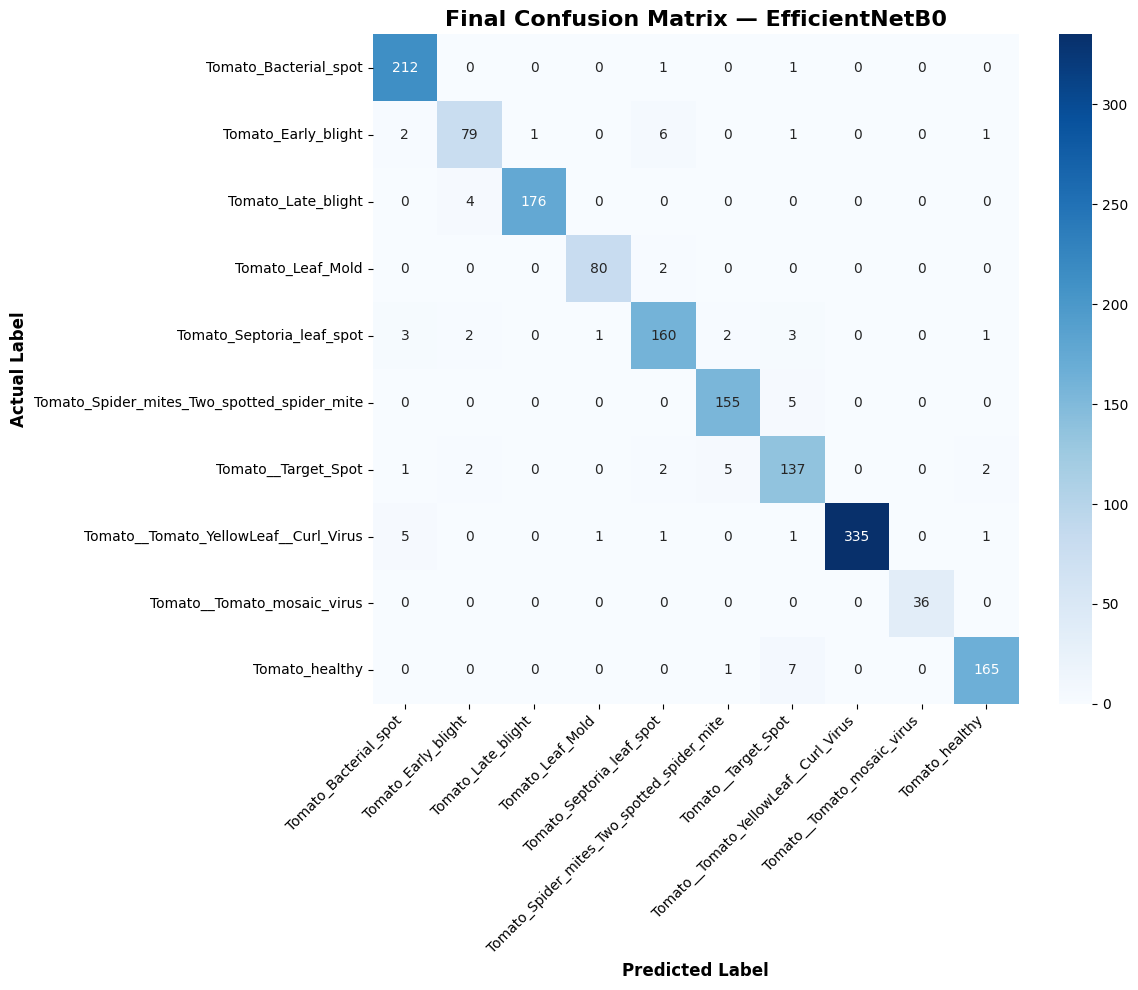


       CLASSIFICATION REPORT: EFFICIENTNET-B0
                                             precision    recall  f1-score   support

                      Tomato_Bacterial_spot       0.95      0.99      0.97       214
                        Tomato_Early_blight       0.91      0.88      0.89        90
                         Tomato_Late_blight       0.99      0.98      0.99       180
                           Tomato_Leaf_Mold       0.98      0.98      0.98        82
                  Tomato_Septoria_leaf_spot       0.93      0.93      0.93       172
Tomato_Spider_mites_Two_spotted_spider_mite       0.95      0.97      0.96       160
                        Tomato__Target_Spot       0.88      0.92      0.90       149
      Tomato__Tomato_YellowLeaf__Curl_Virus       1.00      0.97      0.99       344
                Tomato__Tomato_mosaic_virus       1.00      1.00      1.00        36
                             Tomato_healthy       0.97      0.95      0.96       173

                

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os
from sklearn.metrics import classification_report, confusion_matrix

print("========== PHASE 3: FINAL EVALUATION — EFFICIENTNET-B0 ==========")

# 1. Safely Extract Class Names
if hasattr(test_ds, 'class_names'):
    eval_class_names = test_ds.class_names
elif 'class_names' in globals() and class_names is not None:
    eval_class_names = class_names
else:
    dataset_dir = '/content/PlantVillage_Tomato'
    eval_class_names = sorted([d for d in os.listdir(dataset_dir) if os.path.isdir(os.path.join(dataset_dir, d))])

# 2. Prepare High-Speed Test Stream
AUTOTUNE = tf.data.AUTOTUNE
fast_test_ds = test_ds.cache().prefetch(AUTOTUNE)

# 3. Rebuild Architecture and Load Fine-Tuned Weights
model_eff = build_health_engine('EfficientNetB0')
weights_path_eff = "EfficientNetB0_FINETUNED_best.weights.h5"

model_eff.load_weights(weights_path_eff)
print(f"✅ Loaded fine-tuned weights from: {weights_path_eff}")

# 4. Overall Loss & Accuracy
print("\nCalculating overall test dataset metrics for EfficientNetB0...")
test_loss_eff, test_acc_eff = model_eff.evaluate(fast_test_ds, verbose=1)
print(f"\n🎯 EFFICIENTNET-B0 TEST ACCURACY : {test_acc_eff * 100:.2f}%")
print(f"📉 EFFICIENTNET-B0 TEST LOSS     : {test_loss_eff:.4f}")

# 5. Generate Predictions
print("\nExtracting predictions...")
y_true_eff = []
y_pred_eff = []

for images, labels in fast_test_ds:
    preds = model_eff.predict(images, verbose=0)
    y_pred_eff.extend(np.argmax(preds, axis=1))
    y_true_eff.extend(labels.numpy())

y_true_eff = np.array(y_true_eff)
y_pred_eff = np.array(y_pred_eff)

# 6. Confusion Matrix Heatmap
cm_eff = confusion_matrix(y_true_eff, y_pred_eff)

plt.figure(figsize=(12, 10))
sns.heatmap(cm_eff, annot=True, fmt='d', cmap='Blues',
            xticklabels=eval_class_names, yticklabels=eval_class_names)
plt.title('Final Confusion Matrix — EfficientNetB0', fontsize=16, fontweight='bold')
plt.ylabel('Actual Label', fontsize=12, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# 7. Classification Report & Per-Class Breakdown
print("\n" + "="*60)
print("       CLASSIFICATION REPORT: EFFICIENTNET-B0")
print("="*60)
print(classification_report(y_true_eff, y_pred_eff, target_names=eval_class_names))

cm_diag_eff = cm_eff.diagonal()
cm_sum_eff = cm_eff.sum(axis=1)
stats_df_eff = pd.DataFrame({
    'Disease Class': eval_class_names,
    'Correct': cm_diag_eff,
    'Total': cm_sum_eff,
    'Accuracy (%)': np.round((cm_diag_eff / cm_sum_eff) * 100, 2)
})

print("\n" + "="*60)
print("       PER-CLASS ACCURACY: EFFICIENTNET-B0")
print("="*60)
print(stats_df_eff.to_string(index=False))

# ResNet50 Final Evaluation

========== PHASE 3: FINAL EVALUATION — RESNET-50 ==========


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 78 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


✅ Loaded fine-tuned weights from: ResNet50_FINETUNED_best.weights.h5

Calculating overall test dataset metrics for ResNet50...
50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 88ms/step - accuracy: 0.9444 - loss: 0.1922

🎯 RESNET-50 TEST ACCURACY : 94.44%
📉 RESNET-50 TEST LOSS     : 0.1922

Extracting predictions...


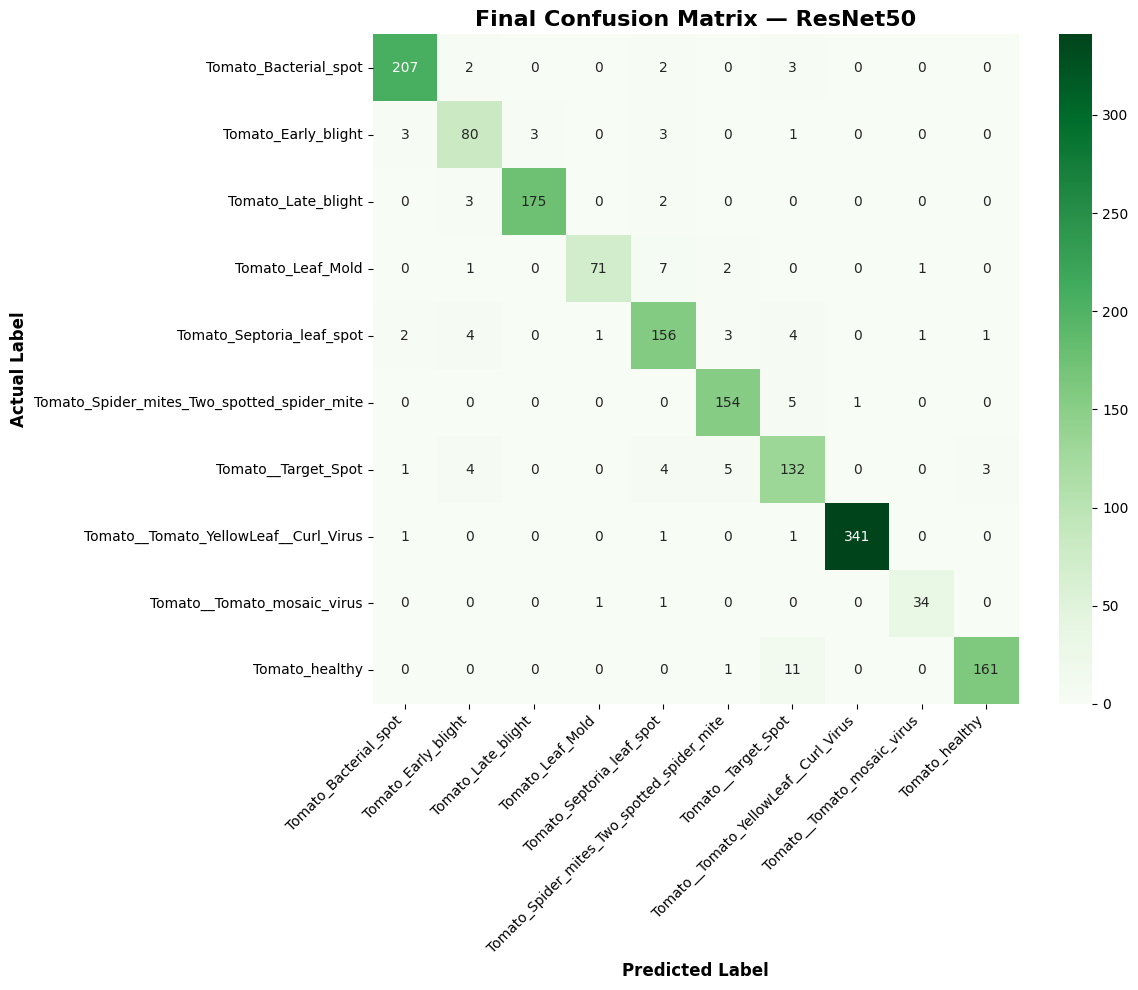


       CLASSIFICATION REPORT: RESNET-50
                                             precision    recall  f1-score   support

                      Tomato_Bacterial_spot       0.97      0.97      0.97       214
                        Tomato_Early_blight       0.85      0.89      0.87        90
                         Tomato_Late_blight       0.98      0.97      0.98       180
                           Tomato_Leaf_Mold       0.97      0.87      0.92        82
                  Tomato_Septoria_leaf_spot       0.89      0.91      0.90       172
Tomato_Spider_mites_Two_spotted_spider_mite       0.93      0.96      0.95       160
                        Tomato__Target_Spot       0.84      0.89      0.86       149
      Tomato__Tomato_YellowLeaf__Curl_Virus       1.00      0.99      0.99       344
                Tomato__Tomato_mosaic_virus       0.94      0.94      0.94        36
                             Tomato_healthy       0.98      0.93      0.95       173

                      

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os
from sklearn.metrics import classification_report, confusion_matrix

print("========== PHASE 3: FINAL EVALUATION — RESNET-50 ==========")

# 1. Safely Extract Class Names
if hasattr(test_ds, 'class_names'):
    eval_class_names = test_ds.class_names
elif 'class_names' in globals() and class_names is not None:
    eval_class_names = class_names
else:
    dataset_dir = '/content/PlantVillage_Tomato'
    eval_class_names = sorted([d for d in os.listdir(dataset_dir) if os.path.isdir(os.path.join(dataset_dir, d))])

# 2. Prepare High-Speed Test Stream
AUTOTUNE = tf.data.AUTOTUNE
fast_test_ds = test_ds.cache().prefetch(AUTOTUNE)

# 3. Rebuild Architecture and Load Fine-Tuned Weights
model_res = build_health_engine('ResNet50')
weights_path_res = "ResNet50_FINETUNED_best.weights.h5"

model_res.load_weights(weights_path_res)
print(f"✅ Loaded fine-tuned weights from: {weights_path_res}")

# 4. Overall Loss & Accuracy
print("\nCalculating overall test dataset metrics for ResNet50...")
test_loss_res, test_acc_res = model_res.evaluate(fast_test_ds, verbose=1)
print(f"\n🎯 RESNET-50 TEST ACCURACY : {test_acc_res * 100:.2f}%")
print(f"📉 RESNET-50 TEST LOSS     : {test_loss_res:.4f}")

# 5. Generate Predictions
print("\nExtracting predictions...")
y_true_res = []
y_pred_res = []

for images, labels in fast_test_ds:
    preds = model_res.predict(images, verbose=0)
    y_pred_res.extend(np.argmax(preds, axis=1))
    y_true_res.extend(labels.numpy())

y_true_res = np.array(y_true_res)
y_pred_res = np.array(y_pred_res)

# 6. Confusion Matrix Heatmap
cm_res = confusion_matrix(y_true_res, y_pred_res)

plt.figure(figsize=(12, 10))
# Using a different color map (Greens) to visually distinguish from EfficientNet
sns.heatmap(cm_res, annot=True, fmt='d', cmap='Greens',
            xticklabels=eval_class_names, yticklabels=eval_class_names)
plt.title('Final Confusion Matrix — ResNet50', fontsize=16, fontweight='bold')
plt.ylabel('Actual Label', fontsize=12, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# 7. Classification Report & Per-Class Breakdown
print("\n" + "="*60)
print("       CLASSIFICATION REPORT: RESNET-50")
print("="*60)
print(classification_report(y_true_res, y_pred_res, target_names=eval_class_names))

cm_diag_res = cm_res.diagonal()
cm_sum_res = cm_res.sum(axis=1)
stats_df_res = pd.DataFrame({
    'Disease Class': eval_class_names,
    'Correct': cm_diag_res,
    'Total': cm_sum_res,
    'Accuracy (%)': np.round((cm_diag_res / cm_sum_res) * 100, 2)
})

print("\n" + "="*60)
print("       PER-CLASS ACCURACY: RESNET-50")
print("="*60)
print(stats_df_res.to_string(index=False))

# Save model

In [ ]:
import tensorflow as tf
import os
from google.colab import drive

print("--- Phase 3: Deployment & Export (Google Drive Edition) ---")



# Create a dedicated folder in your Drive
drive_path = '/content/drive/MyDrive/Bsc_Thesis'
os.makedirs(drive_path, exist_ok=True)

# Pointing explicitly to the EfficientNet model
export_model = model_eff

# 2. Master Backup: Save in standard Keras format to Drive
keras_model_path = os.path.join(drive_path, "health_engine_efficientnet_final.keras")
export_model.save(keras_model_path)
print(f"✅ Saved standard Keras model to {keras_model_path}")

# 3. Edge Quantization: Convert to TFLite
print("⚙️ Converting and quantizing to TensorFlow Lite format...")
converter = tf.lite.TFLiteConverter.from_keras_model(export_model)

# Apply default optimizations to shrink the weights
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()

# 4. Save the Quantized Model to Drive
tflite_model_path = os.path.join(drive_path, "health_engine_efficientnet_quantized.tflite")
with open(tflite_model_path, "wb") as f:
    f.write(tflite_model)

# 5. Output Verification
keras_size_mb = os.path.getsize(keras_model_path) / (1024 * 1024)
tflite_size_mb = os.path.getsize(tflite_model_path) / (1024 * 1024)
compression_ratio = keras_size_mb / tflite_size_mb

print("\n=======================================================")
print("🚀 SUCCESS: EfficientNet Models exported securely to Google Drive!")
print("=======================================================")
print(f"📦 Original Keras Size  : {keras_size_mb:.2f} MB")
print(f"📱 Quantized TFLite Size: {tflite_size_mb:.2f} MB")
print(f"📉 Compression Ratio    : {compression_ratio:.1f}x smaller")

--- Phase 3: Deployment & Export (Google Drive Edition) ---
✅ Saved standard Keras model to /content/drive/MyDrive/Bsc_Thesis/health_engine_efficientnet_final.keras
⚙️ Converting and quantizing to TensorFlow Lite format...
Saved artifact at '/tmp/tmp6s1kr49z'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_714')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  135523753190096: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  135523753191824: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  135526020532752: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135521322730512: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135521322729552: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135523755018192: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135525996837584: TensorSpec(shape=(), dtype=tf.r

In [ ]:
import tensorflow as tf

print("--- Verifying Saved Model Architecture ---")

# Point to the exact file on your Google Drive
verification_path = '/content/drive/MyDrive/Bsc_Thesis/health_engine_efficientnet_final.keras'

# Load the model directly from the saved file
saved_model = tf.keras.models.load_model(verification_path)

# Scan the internal layers to identify the base architecture
for layer in saved_model.layers:
    if isinstance(layer, tf.keras.Model):
        print(f"✅ VERIFIED: The base model inside this file is exactly: '{layer.name}'")

--- Verifying Saved Model Architecture ---
✅ VERIFIED: The base model inside this file is exactly: 'efficientnetb0'


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 6 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
